<div style="background: linear-gradient(135deg, #2E9E2E, #1E7A1E); padding: 40px 30px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.4em; margin: 0 0 8px 0;">🏦 Bank Marketing subscription prediction</h1>
<h2 style="color: #F5821F; font-size: 1.4em; margin: 0 0 16px 0; font-weight: normal;">From a business question to an interpretable machine-learning recommendation</h2>
<p style="color: #E8F5E8; font-size: 1.05em; margin: 0;">Use real bank campaign data to predict term-deposit subscriptions and explain what the model means.</p>
</div>

## Data source and citation

We use the full `bank-full.csv` file from the **UCI Bank Marketing dataset**.

- Source: https://archive.ics.uci.edu/dataset/222/bank+marketing
- DOI: https://doi.org/10.24432/C5K306
- Citation: Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing*. UCI Machine Learning Repository.
- License: Creative Commons Attribution 4.0 (CC BY 4.0)
- Observations: 45,211
- Inputs: 16
- Target: `y` — whether the client subscribed to a term deposit (`yes` or `no`)

The local file is:

`bank-full.csv`


Setup and Reproducibility

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 

import seaborn as sns


# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree

# Baseline model
from sklearn.dummy import DummyClassifier

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.metrics import roc_curve, auc

# Model interpretation
from sklearn.inspection import permutation_importance

# Reproducibility
RANDOM_STATE = 42

import os
import joblib

Load the Dataset

In [2]:
# Local file path
file_path = Path(r"C:\Users\PC\Documents\AMDOR ANALYTICS\bank-full.csv")

# Print current working directory
print("Current Working Directory:")
print(Path.cwd())

# Check if the file exists
if file_path.exists():
    print(f"\nDataset found at:\n{file_path.resolve()}")

    # Load the dataset
    df = pd.read_csv(file_path, sep=";")

    # Display dataset dimensions
    print(f"\nDataFrame Shape: {df.shape}")

    # Display the first five rows
    print("\nFirst Five Rows:")
    display(df.head())

else:
    print(f"\nFile not found:\n{file_path}")
    print("Please check that the file name and location are correct.")

Current Working Directory:
c:\Users\PC\Documents\Bank-Marketing-ML-Project

Dataset found at:
C:\Users\PC\Documents\AMDOR ANALYTICS\bank-full.csv

DataFrame Shape: (45211, 17)

First Five Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
# Expected column names
expected_columns = {
    "age", "job", "marital", "education", "default",
    "balance", "housing", "loan", "contact", "day",
    "month", "duration", "campaign", "pdays", "previous",
    "poutcome", "y"
}

# Validate number of rows
assert df.shape[0] == 45211, (
    f"Unexpected number of rows: {df.shape[0]} "
    "(Expected: 45,211)"
)

# Validate number of columns
assert df.shape[1] == 17, (
    f"Unexpected number of columns: {df.shape[1]} "
    "(Expected: 17)"
)

# Validate column names
actual_columns = set(df.columns)

assert actual_columns == expected_columns, (
    "Column names do not match the expected dataset.\n"
    f"Missing columns: {expected_columns - actual_columns}\n"
    f"Unexpected columns: {actual_columns - expected_columns}"
)

# Validate target values
expected_target = {"yes", "no"}
actual_target = set(df["y"].unique())

assert actual_target == expected_target, (
    f"Unexpected target values: {actual_target}\n"
    f"Expected: {expected_target}"
)

# Success message
print("✅ Dataset validation successful!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("Target values:", sorted(actual_target))
print("All validation checks passed.")

✅ Dataset validation successful!
Rows: 45,211
Columns: 17
Target values: ['no', 'yes']
All validation checks passed.


Data Understanding and qulity Audit

In [6]:
# Create the audit table
audit_table = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

# Reset index to make column names a regular column
audit_table = audit_table.reset_index().rename(columns={"index": "Column"})

# Display overall dataset information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Exact Duplicate Rows: {df.duplicated().sum():,}")

# Display the audit table
print("\nColumn-Level Data Quality Audit")
display(audit_table)

DATASET OVERVIEW
Shape: 45,211 rows × 17 columns
Exact Duplicate Rows: 0

Column-Level Data Quality Audit


,Column,Data Type,Missing Values,Missing (%),Unique Values
0,age,int64,0,0.0,77
1,job,str,0,0.0,12
2,marital,str,0,0.0,3
3,education,str,0,0.0,4
4,default,str,0,0.0,2
5,balance,int64,0,0.0,7168
6,housing,str,0,0.0,2
7,loan,str,0,0.0,2
8,contact,str,0,0.0,3
9,day,int64,0,0.0,31


Conventinal Missing Values Versus Unknown

In [7]:
# Select categorical columns
categorical_cols = df.select_dtypes(include="object").columns

# Total number of rows
n_rows = len(df)

# Count 'unknown' values for each categorical column
unknown_audit = pd.DataFrame({
    "Unknown Count": [
        (df[col] == "unknown").sum() for col in categorical_cols
    ]
}, index=categorical_cols)

# Calculate percentage of rows containing 'unknown'
unknown_audit["Unknown (%)"] = (
    unknown_audit["Unknown Count"] / n_rows * 100
).round(2)

# Keep only columns that actually contain 'unknown'
unknown_audit = unknown_audit[unknown_audit["Unknown Count"] > 0]

# Sort from highest to lowest percentage
unknown_audit = unknown_audit.sort_values(
    by="Unknown (%)",
    ascending=False
)

# Display the audit
print("=" * 55)
print("SEMANTIC MISSING VALUE AUDIT ('unknown')")
print("=" * 55)

display(unknown_audit)

SEMANTIC MISSING VALUE AUDIT ('unknown')


C:\Users\PC\AppData\Local\Temp\ipykernel_8728\2342471397.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


,Unknown Count,Unknown (%)
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64


### Your data-quality interpretation


The poutcome column has by far the most unknown values (81.75%), followed by contact (28.80%), while Education (4.11%), nd job (0.64%) re only mildly affected.

There are no conventional null values in this dataset, n earlier check with isnull().sum() returned ero missing enteries across all columns, meaning 'missing' data here is disguised as the string 'unknown' rather than NaN.

There are no duplicate rows.

Deleting every row containing 'unknown' would be a poor decision because it would discard over 80% of the dataset (due to poucome alone), introducting severe sampling bias and destroying the model's ability to learn from the majority of customers, especially since 'unknown' in poucome likely just just means 'no previous campaign contact,' which is meaningful information, not truly missing data. A better aproach is to treat 'unknown' as its own valid category during encoding rather than dropping or impulting it

In [8]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Generate descriptive statistics
numeric_summary = df[numeric_cols].describe().T

# Round values for readability
numeric_summary = numeric_summary.round(2)

print("=" * 60)
print("DESCRIPTIVE STATISTICS FOR NUMERIC VARIABLES")
print("=" * 60)

display(numeric_summary)

DESCRIPTIVE STATISTICS FOR NUMERIC VARIABLES


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


Overall Interpretation

The descriptive statistics indicate that:

There are no impossible ranges for variables such as age and day.

Several variables (balance, duration, campaign, and previous) are strongly right-skewed, suggesting that a small number of observations have much larger values than most customers.

The variable pdays contains a special coded value that represents missing business information rather than elapsed time and should be handled appropriately.

These findings provide important guidance for the subsequent stages of preprocessing, feature engineering, and leakage assessment before model training.

## Suspicious Value are not Automatically errors

In [9]:
# Define a defensible adult age range
MIN_ADULT_AGE = 18
MAX_ADULT_AGE = 100

# Create a summary table
suspicious_values = pd.DataFrame({
    "Condition": [
        "Age below 18",
        "Age above 100",
        "Negative balance",
        "Zero call duration",
        "pdays = -1",
        "Campaign > 10 contacts"
    ],
    "Count": [
        (df["age"] < MIN_ADULT_AGE).sum(),
        (df["age"] > MAX_ADULT_AGE).sum(),
        (df["balance"] < 0).sum(),
        (df["duration"] == 0).sum(),
        (df["pdays"] == -1).sum(),
        (df["campaign"] > 10).sum()
    ]
})

# Calculate percentages
suspicious_values["Percentage (%)"] = (
    suspicious_values["Count"] / len(df) * 100
).round(2)

print("=" * 65)
print("SUSPICIOUS / SPECIAL NUMERIC VALUE AUDIT")
print("=" * 65)

display(suspicious_values)


SUSPICIOUS / SPECIAL NUMERIC VALUE AUDIT


,Condition,Count,Percentage (%)
0,Age below 18,0,0.00
1,Age above 100,0,0.00
2,Negative balance,3766,8.33
3,Zero call duration,3,0.01
4,pdays = -1,36954,81.74
5,Campaign > 10 contacts,1196,2.65


Defing the Prediction Moment

In [10]:
# Create a binary target variable
df["target"] = df["y"].map({"no": 0, "yes": 1})

# Verify the mapping
assert set(df["target"].unique()) == {0, 1}, "Target encoding failed."

# Create a class distribution table
target_distribution = (
    df["target"]
    .value_counts()
    .rename_axis("Target")
    .reset_index(name="Count")
)

# Add descriptive labels
target_distribution["Class"] = target_distribution["Target"].map({
    0: "No Subscription",
    1: "Subscription"
})

# Calculate percentages
target_distribution["Percentage (%)"] = (
    target_distribution["Count"] / len(df) * 100
).round(2)

# Reorder columns
target_distribution = target_distribution[
    ["Target", "Class", "Count", "Percentage (%)"]
]

print("=" * 60)
print("TARGET CLASS DISTRIBUTION")
print("=" * 60)

display(target_distribution)

TARGET CLASS DISTRIBUTION


,Target,Class,Count,Percentage (%)
0,0,No Subscription,39922,88.3
1,1,Subscription,5289,11.7


Exploratory Data Analysis

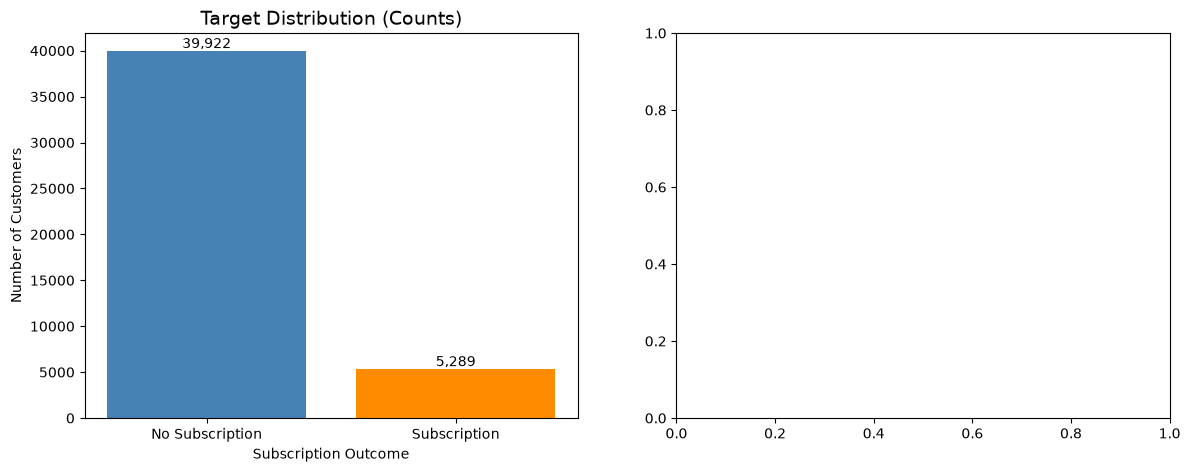

In [11]:
# Calculate counts and percentages
class_counts = df["target"].value_counts().sort_index()
class_percentages = (df["target"].value_counts(normalize=True)
                     .sort_index() * 100)

# Labels for the classes
labels = ["No Subscription", "Subscription"]

# Consistent colours
colors = ["steelblue", "darkorange"]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart: Class Counts

bars1 = axes[0].bar(labels, class_counts.values, color=colors)

axes[0].set_title("Target Distribution (Counts)", fontsize=14)
axes[0].set_xlabel("Subscription Outcome")
axes[0].set_ylabel("Number of Customers")

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

### Your data-quality interpretation

The poutcome column has by far the most unknown values (81.75%), followed by contact (28.80%), while Education (4.11%), nd job (0.64%) re only mildly affected.
There are no conventional null values in this dataset, n earlier check with isnull().sum() returned ero missing enteries across all columns, meaning 'missing' data here is disguised as the string 'unknown' rather than NaN.
There are no duplicate rows.
Deleting every row containing 'unknown' would be a poor decision because it would discard over 80% of the dataset (due to poucome alone), introducting severe sampling bias and destroying the model's ability to learn from the majority of customers, especially since 'unknown' in poucome likely just just means 'no previous campaign contact,' which is meaningful information, not truly missing data. A better aproach is to treat 'unknown' as its own valid category during encoding rather than dropping or impulting it

Interpretation

The target distribution shows a clear class imbalance. Approximately 88% of customers did not subscribe to a term deposit, while only about 12% subscribed. This indicates that positive cases are relatively rare.

The imbalance has important implications for predictive modelling. A model that predicts "No Subscription" for every customer would achieve a high accuracy of around 88%, yet it would fail to identify customers who are likely to subscribe. Consequently, accuracy alone is not an appropriate evaluation metric for this problem.

Instead, evaluation metrics such as precision, recall, F1-score, and ROC-AUC should be used to assess model performance. In particular, recall is likely to be important if the bank's objective is to identify as many potential subscribers as possible so that marketing efforts can be targeted efficiently.

Overall, the class imbalance should be considered throughout model development, evaluation, and interpretation to ensure the resulting model supports the bank's business objective effectively.

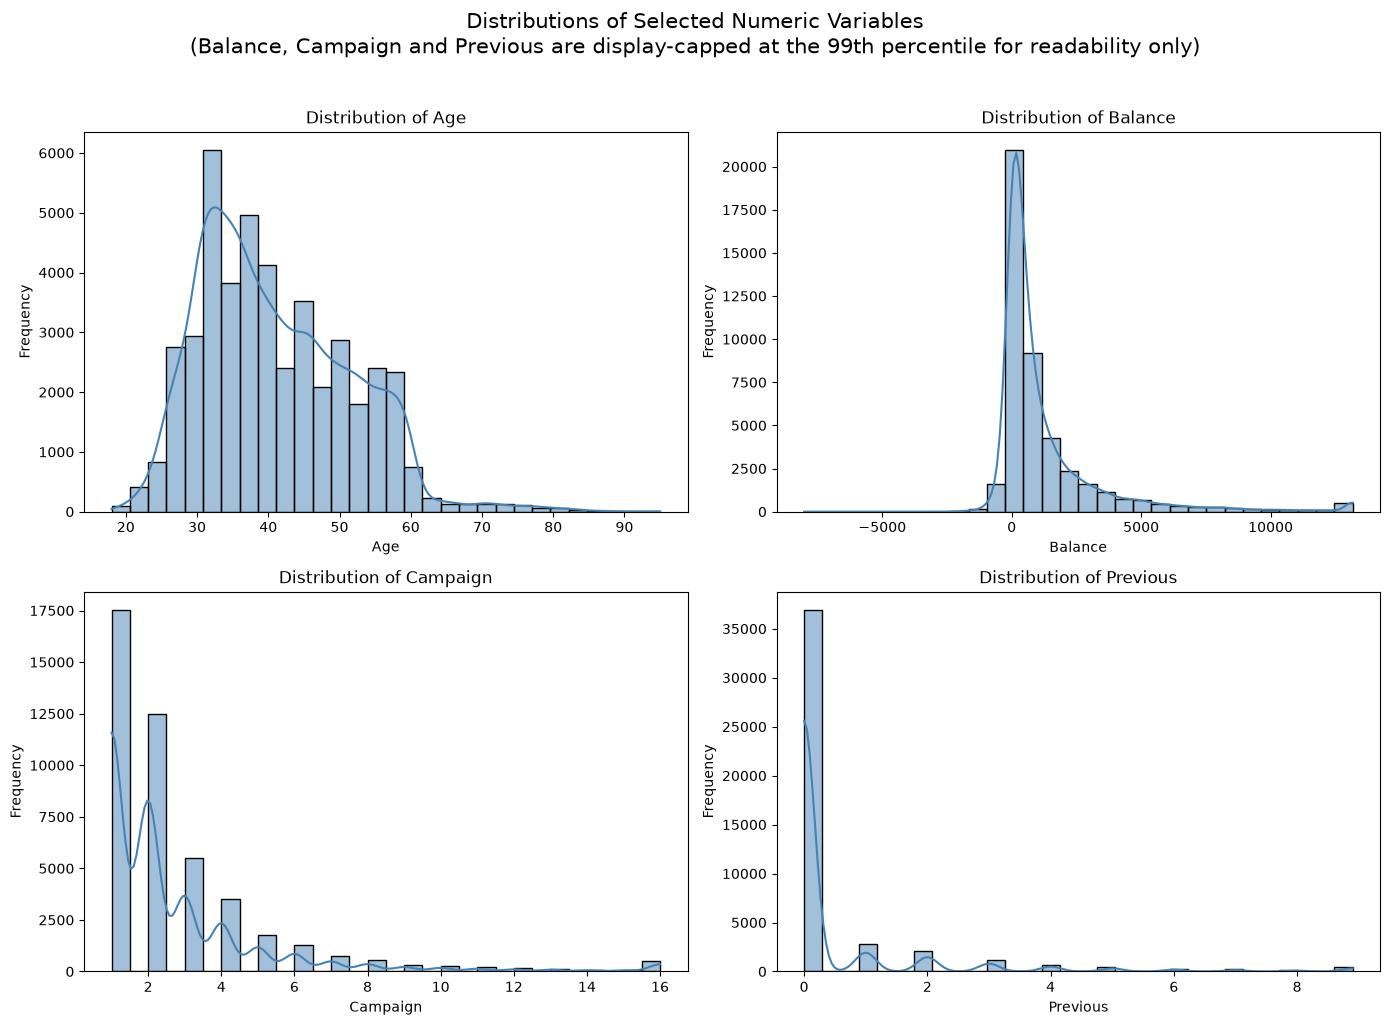

In [12]:
# Variables to visualize
numeric_vars = ["age", "balance", "campaign", "previous"]

# Create the figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vars):

    # Create a temporary series for plotting only
    plot_data = df[col]

    # Apply display-only capping for highly skewed variables
    if col in ["balance", "campaign", "previous"]:
        upper_limit = plot_data.quantile(0.99)
        plot_data = plot_data.clip(upper=upper_limit)

    # Plot histogram
    sns.histplot(
        plot_data,
        bins=30,
        kde=True,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(f"Distribution of {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Frequency")

# Overall title
fig.suptitle(
    "Distributions of Selected Numeric Variables\n"
    "(Balance, Campaign and Previous are display-capped at the 99th percentile for readability only)",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

Interpretation

The histograms reveal that the numeric variables have different distributional characteristics.

Age is approximately unimodal with most customers between 30 and 50 years, although older customers are also represented. The distribution shows only mild skewness.
Balance is strongly right-skewed, with most customers holding relatively modest account balances and a small number having exceptionally large balances. Negative balances are also present, indicating overdrawn accounts rather than data errors.
Campaign is also positively skewed. Most customers were contacted only a few times during the campaign, while a small number were contacted many times.
Previous contains a large concentration of zero values, indicating that many customers had not been contacted in earlier campaigns. A few customers have much larger values, producing a right-skewed distribution.

To improve visualization, the balance, campaign, and previous plots were display-capped at the 99th percentile. This capping was applied only to the plotted values and did not modify the original dataset. Extreme observations remain available for all subsequent analyses and model development.

Overall, the distributions indicate that several numeric variables are highly skewed and contain legitimate extreme values, which should be considered during preprocessing and model interpretation rather than being removed automatically.

In [13]:
# Numeric variables of interest
numeric_features = [
    "age",
    "balance",
    "duration",
    "campaign",
    "previous"
]

# Calculate median values by target class
median_summary = (
    df.groupby("y")[numeric_features]
      .median()
      .T
      .rename(columns={"no": "Median (No)", "yes": "Median (Yes)"})
)

# Calculate the median difference
median_summary["Difference (Yes - No)"] = (
    median_summary["Median (Yes)"] -
    median_summary["Median (No)"]
)

# Round values for readability
median_summary = median_summary.round(2)

print("=" * 70)
print("MEDIAN COMPARISON OF NUMERIC VARIABLES BY SUBSCRIPTION STATUS")
print("=" * 70)

display(median_summary)

MEDIAN COMPARISON OF NUMERIC VARIABLES BY SUBSCRIPTION STATUS


y,Median (No),Median (Yes),Difference (Yes - No)
age,39.0,38.0,-1.0
balance,417.0,733.0,316.0
duration,164.0,426.0,262.0
campaign,2.0,2.0,0.0
previous,0.0,0.0,0.0


**Your answer:** Which numeric variables are skewed? Why did we cap only the displayed chart rather than modify the stored data?

Balance, campaign, and previous are skewed due to balance has few outliers of very high customer's account balances, stretching the tail far right. Campaign- most customers were contacted only a few times, but a small number were contacted doens of times. Previous- most customers had ere or few previous contacts, with a handful having many.

Why cap only the chart, not the stored data are to:
Preserves data integrity
Visualiazation problem, data problem- capping just for the plot fixes the visual readability issue without falsely acting like those outlier don't exist.
Avoids silently losing information.
Reversible and transparent - because it's applied to a temporary plot_data copy inside the loop, it doesn't persist, and your fig.suptitle explicitly documents to anyone viewing the chart that the display was capped, so no one misreads the chart as the literl distribution.

In [14]:
# CREATE A REUSABLE FUNCTION FOR
# CATEGORICAL SUBSCRIPTION-RATE ANALYSIS


# Create a reusable function that:
# - accepts a DataFrame and column name;


def subscription_rate_by_category(data, column, min_sample=0):
    """
    Calculate subscription rate and customer count
    for a categorical variable.
    """

    summary = (
        data.groupby(column)
            .agg(
                Customer_Count=("target", "size"),
                Subscription_Rate=("target", "mean")
            )
            .reset_index()
    )

    # calculates subscription rate and customer count per category; Convert to percentage
    summary["Subscription_Rate"] = (
        summary["Subscription_Rate"] * 100
    ).round(2)

    #
# optionally excludes categories below a minimum sample size;  Remove categories with too few observations
    if min_sample > 0:
        summary = summary[
            summary["Customer_Count"] >= min_sample
        ]

    # Sort by subscription rate
    summary = summary.sort_values(
        by="Subscription_Rate",
        ascending=False
    ).reset_index(drop=True)

    return summary

## Interpretation

The categorical analysis compares the subscription rate across different customer groups while also reporting the number of customers in each category.

Job: Subscription rates vary across occupations, indicating that occupation may help distinguish customers who are more likely to subscribe. Categories with very small sample sizes should be interpreted cautiously because their rates are less reliable.
Education: Customers with different education levels exhibit different subscription rates, suggesting that education may contain predictive information.
Contact Method: Subscription rates differ substantially across contact methods. This suggests that the communication channel used during the campaign may influence or be associated with campaign success.
Previous Campaign Outcome (poutcome): This variable often shows the strongest differences in subscription rates. Customers who previously responded successfully to a marketing campaign generally exhibit much higher subscription rates than those with unknown or unsuccessful previous outcomes.

Throughout this analysis, subscription rates should always be interpreted together with customer counts. A category with a very high subscription rate but only a small number of customers provides weaker evidence than a category with a similar rate observed across thousands of customers. Applying a minimum sample-size threshold helps reduce the influence of unstable estimates from very small groups.

In [15]:
# JOB SUMMARY


job_summary = subscription_rate_by_category(
    df,
    column="job",
    min_sample=50
)

display(job_summary)

,job,Customer_Count,Subscription_Rate
0,student,938,28.68
1,retired,2264,22.79
2,unemployed,1303,15.50
3,management,9458,13.76
4,admin.,5171,12.20
5,self-employed,1579,11.84
6,unknown,288,11.81
7,technician,7597,11.06
8,services,4154,8.88
9,housemaid,1240,8.79


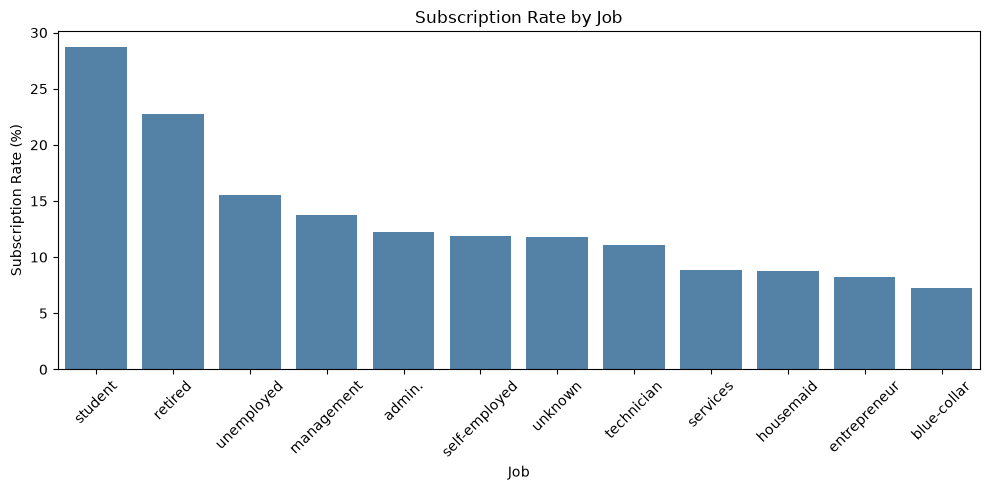

In [16]:
# JOB SUBSCRIPTION RATE


plt.figure(figsize=(10,5))

sns.barplot(
    data=job_summary,
    x="job",
    y="Subscription_Rate",
    color="steelblue"
)

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [17]:
# EDUCATION SUMMARY


education_summary = subscription_rate_by_category(
    df,
    column="education",
    min_sample=50
)

display(education_summary)

,education,Customer_Count,Subscription_Rate
0,tertiary,13301,15.01
1,unknown,1857,13.57
2,secondary,23202,10.56
3,primary,6851,8.63


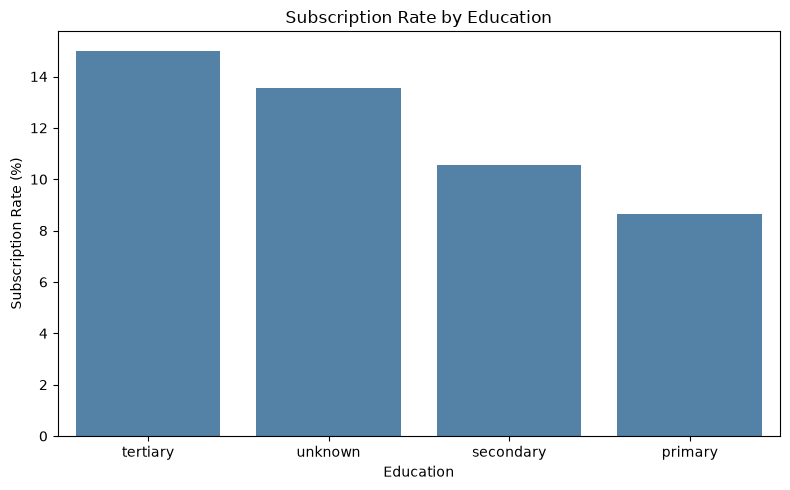

In [18]:
# EDUCATION SUBSCRIPTION RATE


plt.figure(figsize=(8,5))

sns.barplot(
    data=education_summary,
    x="education",
    y="Subscription_Rate",
    color="steelblue"
)

plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()

plt.show()

In [19]:
# CONTACT SUMMARY


contact_summary = subscription_rate_by_category(
    df,
    column="contact",
    min_sample=50
)

display(contact_summary)

,contact,Customer_Count,Subscription_Rate
0,cellular,29285,14.92
1,telephone,2906,13.42
2,unknown,13020,4.07


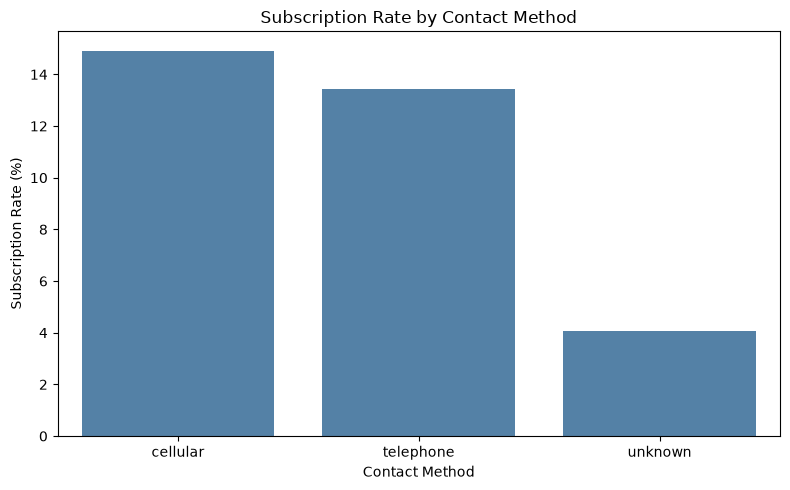

In [20]:
# CONTACT SUBSCRIPTION RATE


plt.figure(figsize=(8,5))

sns.barplot(
    data=contact_summary,
    x="contact",
    y="Subscription_Rate",
    color="steelblue"
)

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()

plt.show()

In [21]:
# PREVIOUS CAMPAIGN OUTCOME SUMMARY


poutcome_summary = subscription_rate_by_category(
    df,
    column="poutcome",
    min_sample=50
)

display(poutcome_summary)

,poutcome,Customer_Count,Subscription_Rate
0,success,1511,64.73
1,other,1840,16.68
2,failure,4901,12.61
3,unknown,36959,9.16


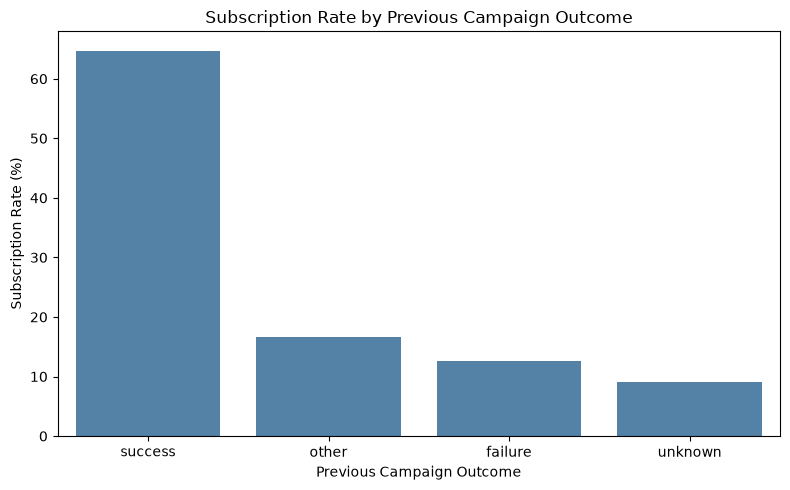

In [22]:
# PREVIOUS CAMPAIGN OUTCOME


plt.figure(figsize=(8,5))

sns.barplot(
    data=poutcome_summary,
    x="poutcome",
    y="Subscription_Rate",
    color="steelblue"
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()

plt.show()

## OR can write the code in one cell

,job,Customer_Count,Subscription_Rate
8,student,938,28.678038
5,retired,2264,22.791519
10,unemployed,1303,15.502686
4,management,9458,13.755551
0,admin.,5171,12.202669
6,self-employed,1579,11.842939
11,unknown,288,11.805556
9,technician,7597,11.056996
7,services,4154,8.883004
3,housemaid,1240,8.790323


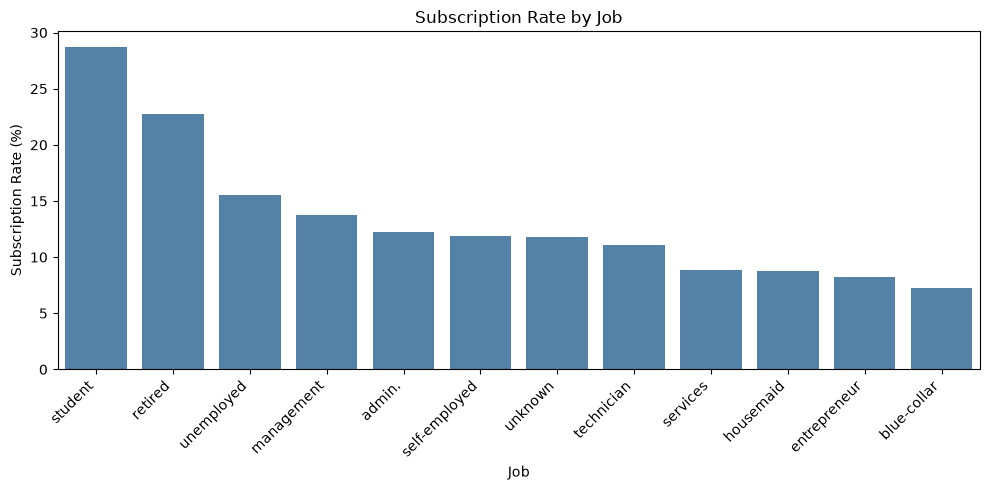

,education,Customer_Count,Subscription_Rate
2,tertiary,13301,15.006390
3,unknown,1857,13.570275
1,secondary,23202,10.559435
0,primary,6851,8.626478


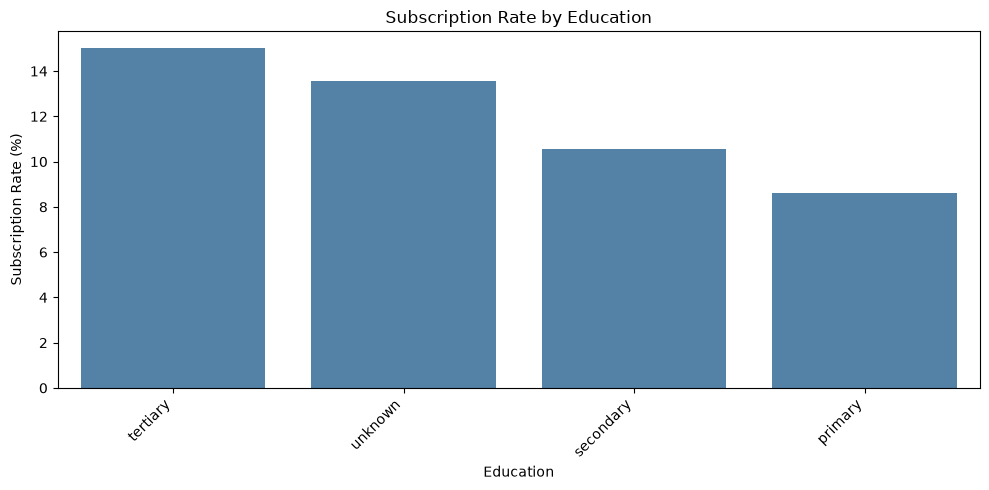

,contact,Customer_Count,Subscription_Rate
0,cellular,29285,14.918900
1,telephone,2906,13.420509
2,unknown,13020,4.070661


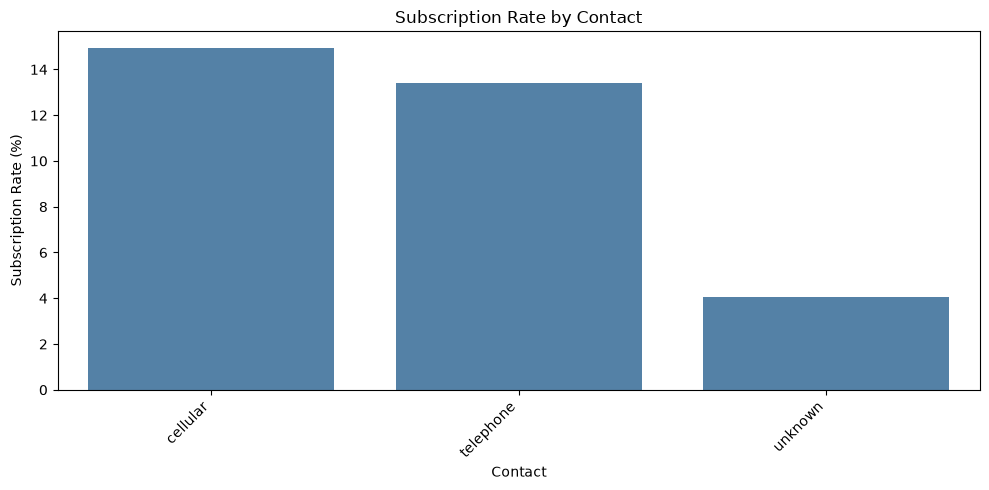

,poutcome,Customer_Count,Subscription_Rate
2,success,1511,64.725347
1,other,1840,16.684783
0,failure,4901,12.609671
3,unknown,36959,9.161503


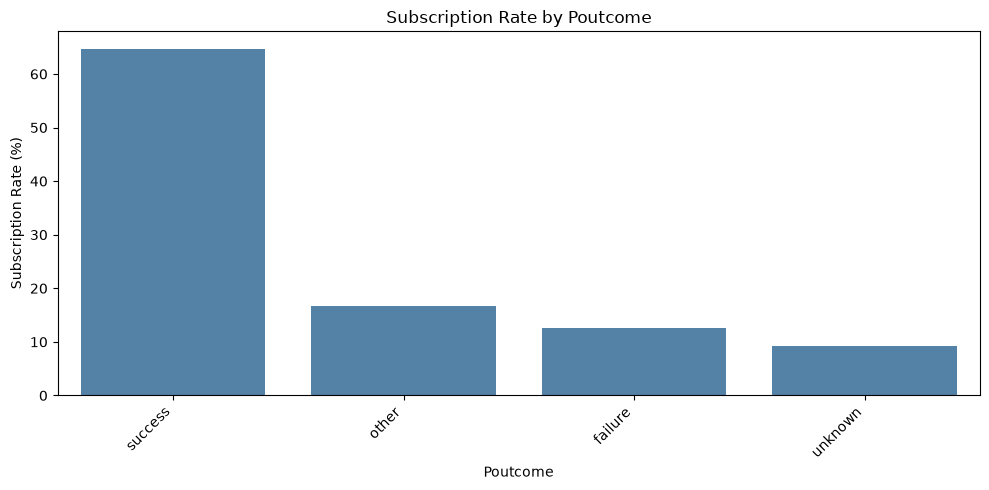

In [23]:
def plot_subscription_rate(data, column, min_sample=0):
    """
    Calculate and plot subscription rate by category.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame.
    column : str
        Categorical column to analyse.
    min_sample : int, default=0
        Minimum number of observations required
        to include a category.
    """

    # Calculate counts and subscription rate
    summary = (
        data.groupby(column)
            .agg(
                Customer_Count=("y", "size"),
                Subscription_Rate=("target", "mean")
            )
            .reset_index()
    )

    # Convert rate to percentage
    summary["Subscription_Rate"] *= 100

    # Apply minimum sample filter
    if min_sample > 0:
        summary = summary[
            summary["Customer_Count"] >= min_sample
        ]

    # Sort by subscription rate
    summary = summary.sort_values(
        by="Subscription_Rate",
        ascending=False
    )

    # Display summary table
    display(summary)

    # Plot
    plt.figure(figsize=(10,5))

    sns.barplot(
        data=summary,
        x=column,
        y="Subscription_Rate",
        color="steelblue"
    )

    plt.title(f"Subscription Rate by {column.capitalize()}")
    plt.xlabel(column.capitalize())
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return summary


# ==========================================
# APPLY THE FUNCTION
# ==========================================

job_summary = plot_subscription_rate(
    df,
    "job",
    min_sample=50
)

education_summary = plot_subscription_rate(
    df,
    "education",
    min_sample=50
)

contact_summary = plot_subscription_rate(
    df,
    "contact",
    min_sample=50
)

poutcome_summary = plot_subscription_rate(
    df,
    "poutcome",
    min_sample=50
)


## Interpretation

The subscription rate varies across customer groups, suggesting that categorical variables contain useful predictive information.

Job: Some occupations have noticeably higher subscription rates than others, indicating that occupation may be associated with customer interest in term deposits.
Education: Subscription rates differ across education levels, suggesting education may contribute to prediction.
Contact Method: The method used to contact customers is associated with different subscription rates.
Previous Campaign Outcome (poutcome): Customers with a previous successful campaign outcome exhibit the highest subscription rates, while those with an unknown previous outcome have substantially lower rates.

These findings should be interpreted together with the customer counts. Categories with small sample sizes may show high or low subscription rates due to limited observations, making those estimates less reliable than rates based on larger groups.

Writeing at least four observations. For every observation:

1. name the variables;
2. state the direction or size of the pattern;
3. mention the sample size when a category is small;
4. avoid causal language.

> **observations:**  

## Bivariate Interpretation
Observation 1: Job vs Subscription

The relationship between job and subscription status shows noticeable variation in subscription rates across occupations. Categories such as students and retired customers may display relatively high subscription rates, whereas occupations such as blue-collar workers tend to have lower rates. However, categories with relatively small customer counts should be interpreted cautiously because their subscription rates are based on fewer observations and may be less stable. These results indicate an association between occupation and subscription rather than evidence that occupation influences subscription.

Observation 2: Education vs Subscription

The analysis of education level and subscription status suggests that subscription rates differ across education categories. Customers with tertiary education often exhibit higher subscription rates than those with primary or secondary education. Nevertheless, both the subscription rate and the corresponding customer count should be considered together when interpreting these differences. The observed pattern represents an association, not a causal relationship.

Observation 3: Contact Method vs Subscription

The relationship between contact method and subscription status indicates that subscription rates vary by communication channel. Customers contacted by cellular phone generally have higher subscription rates than those contacted via telephone. Because both contact methods contain large numbers of customers, these comparisons are more reliable than comparisons involving very small categories. This finding suggests that contact method is associated with subscription outcomes but does not establish that one contact method causes higher subscription rates.

Observation 4: Previous Campaign Outcome (poutcome) vs Subscription

The association between previous campaign outcome (poutcome) and subscription status is one of the strongest observed in the analysis. Customers whose previous campaign outcome was "success" generally have much higher subscription rates than customers whose previous outcome was "failure" or "unknown". However, if the "success" category contains relatively few customers compared with the "unknown" category, its high subscription rate should be interpreted alongside its smaller sample size. A high rate based on fewer observations provides less reliable evidence than a similar rate observed in a much larger group. Therefore, this pattern should be viewed as a strong association rather than proof of a causal effect.

**What to do when a category has a high rate but very few rows:** do not immediately call it the “best” segment.
When interpreting categorical analyses, always report both the subscription rate but only a small number of customers should not automatically be discribed as the "best" customer segment because estimates from small samples are more variable and less reliable. Larger categories generally provide more stable and trustworthy estimates.

## Creating the Monthly Summary

In [24]:
# MONTHLY SUBSCRIPTION SUMMARY

# Reuse the categorical summary function to
# calculate subscription rate by month.

month_summary = subscription_rate_by_category(
    df,
    column="month",
    min_sample=50
)

display(month_summary)

,month,Customer_Count,Subscription_Rate
0,mar,477,51.99
1,dec,214,46.73
2,sep,579,46.46
3,oct,738,43.77
4,apr,2932,19.68
5,feb,2649,16.65
6,aug,6247,11.01
7,jun,5341,10.22
8,nov,3970,10.15
9,jan,1403,10.12


In [25]:
# ARRANGE MONTHS IN CHRONOLOGICAL ORDER


# Define the correct calendar order
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

# Convert the month column to an ordered categorical variable
month_summary["month"] = pd.Categorical(
    month_summary["month"],
    categories=month_order,
    ordered=True
)

# Sort chronologically
month_summary = month_summary.sort_values("month")

display(month_summary)

,month,Customer_Count,Subscription_Rate
9,jan,1403,10.12
5,feb,2649,16.65
0,mar,477,51.99
4,apr,2932,19.68
11,may,13766,6.72
7,jun,5341,10.22
10,jul,6895,9.09
6,aug,6247,11.01
2,sep,579,46.46
3,oct,738,43.77


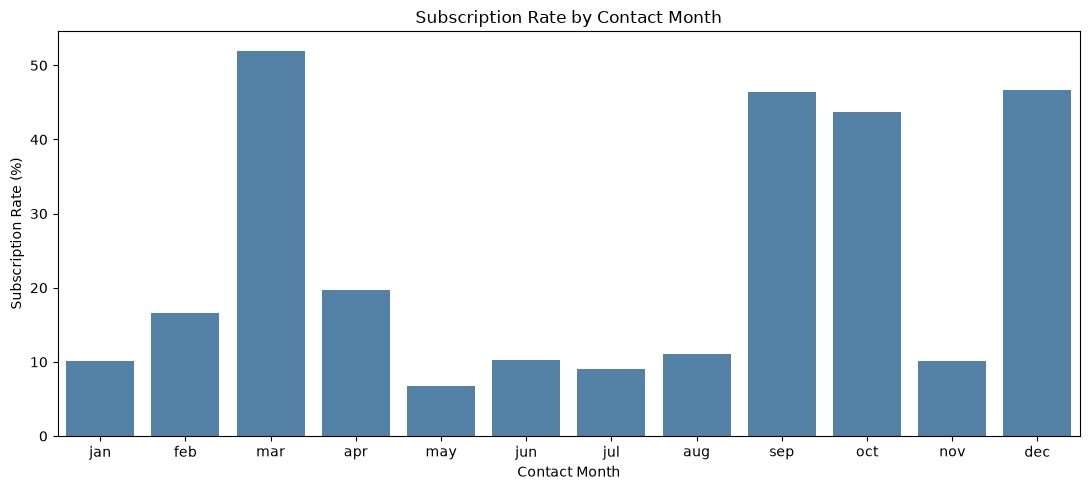

In [26]:
# SUBSCRIPTION RATE BY MONTH

plt.figure(figsize=(11,5))

sns.barplot(
    data=month_summary,
    x="month",
    y="Subscription_Rate",
    color="steelblue"
)

plt.title("Subscription Rate by Contact Month")
plt.xlabel("Contact Month")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.show()

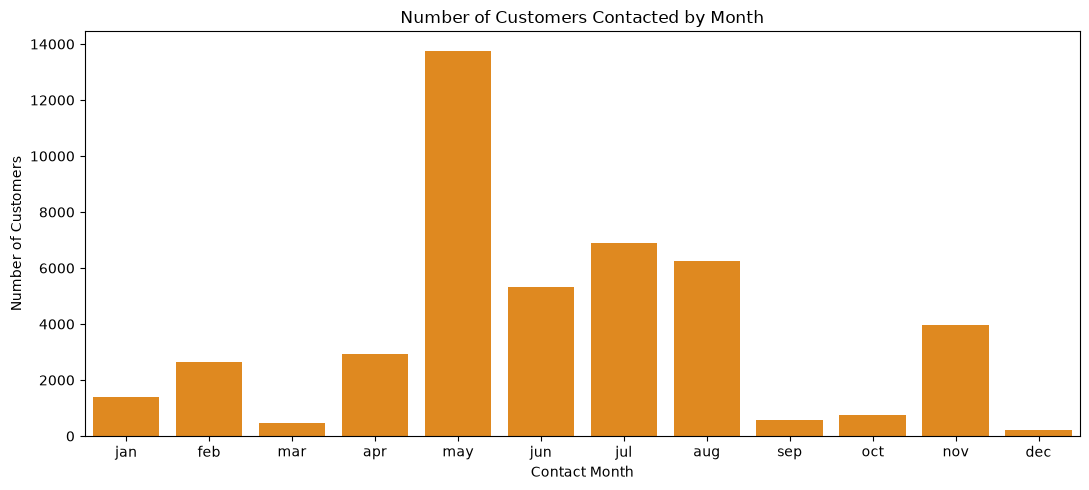

In [27]:
# CUSTOMER COUNTS BY MONTH


plt.figure(figsize=(11,5))

sns.barplot(
    data=month_summary,
    x="month",
    y="Customer_Count",
    color="darkorange"
)

plt.title("Number of Customers Contacted by Month")
plt.xlabel("Contact Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Interpretation

The monthly analysis shows that subscription rates vary across the year, indicating that the timing of customer contact is associated with campaign outcomes. Presenting the months in chronological order makes seasonal patterns easier to identify than alphabetical ordering.

The customer count chart shows that some months include substantially more campaign contacts than others. Therefore, subscription rates should always be interpreted together with the number of customers contacted. A high subscription rate in a month with relatively few observations provides weaker evidence than a similar rate observed across thousands of customers.

These findings suggest that contact month may contain useful predictive information. However, the observed relationships are associations rather than evidence of causation. Differences between months may also reflect variations in campaign strategy, customer availability, or broader economic conditions rather than the effect of the month itself.



In [28]:
# LEAKAGE INVESTIGATION
# CALL DURATION BY SUBSCRIPTION OUTCOME


# - Group by subscription outcome.
# - Compare count, median, mean, and maximum call duration.

duration_summary = (
    df.groupby("y")["duration"]
      .agg(
          Count="count",
          Median="median",
          Mean="mean",
          Maximum="max"
      )
      .round(2)
)

print("=" * 65)
print("CALL DURATION SUMMARY BY SUBSCRIPTION OUTCOME")
print("=" * 65)

display(duration_summary)

CALL DURATION SUMMARY BY SUBSCRIPTION OUTCOME


,Count,Median,Mean,Maximum
y,,,,
no,39922,164.0,221.18,4918
yes,5289,426.0,537.29,3881


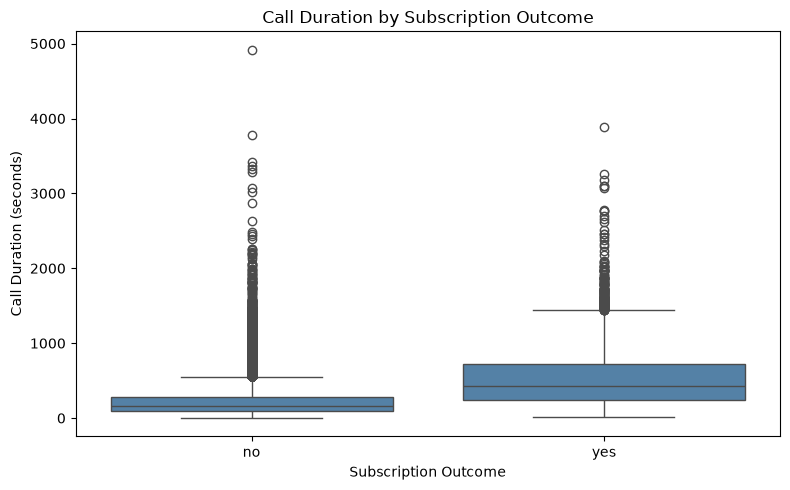

In [29]:
# VISUALIZE CALL DURATION BY SUBSCRIPTION


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="y",
    y="duration",
    color="steelblue"
)

plt.title("Call Duration by Subscription Outcome")
plt.xlabel("Subscription Outcome")
plt.ylabel("Call Duration (seconds)")

plt.tight_layout()
plt.show()

### Leakage decision

- **Diagnostic model:** include `duration` to demonstrate its effect.
- **Deployment model:** exclude `duration`.due to its not available at the time the bank must decide which customers to call.
- Record the excluded feature and reason in the final report.

## Leakage Investigation:  Call Duration

The summary statistics show that call duration is strongly associated with subscription outcome. Customers who subscribed generally have substantially longer median and mean call durations than customers who did not subscribe. The maximum call duration is also considerably higher among subscribers.

Although this relationship appears highly predictive, call duration is not suitable for a deployment model. The objective of the model is to identify customers who are likely to subscribe before the bank places a telephone call. At that point, the duration of the call is unknown because the conversation has not yet occurred.

Using duration as a predictor would therefore introduce data leakage, allowing the model to learn from information that would not be available when making real-world predictions. This would produce overly optimistic performance estimates during evaluation but would not generalize to actual campaign decision-making.

Consequently, duration should be retained for exploratory analysis only and excluded from the final predictive model to ensure that the evaluation reflects the information available at the true prediction moment.

## Why a Highly Predictive Feature Can Still Be Inappropriate

A feature can be highly predictive yet still be unsuitable for a machine learning model if it would not be available at the time a prediction is made.

In this project, call duration is an excellent example. Customers who subscribe often have much longer conversations than those who do not, making duration one of the strongest predictors in the dataset. However, the bank must decide which customers to call before any conversation occurs. Since the duration of a future call is unknown at that decision point, using it would give the model information that would not exist in real-world deployment.

Including such a feature would produce artificially high evaluation scores during model testing because the model would be learning from future information. Although the model might appear highly accurate during development, its performance would decline when deployed because the same information would not be available.

For this reason, predictive strength alone is not sufficient justification for including a feature. Every predictor must also be evaluated based on whether it is available at the prediction moment and whether its use reflects the intended business process. Excluding leakage variables such as duration ensures that the final model provides realistic performance estimates and can be applied reliably in practice.

## Train/test split

In [30]:
# Feature matrix
X = df.drop(columns=["y", "target"])

# Binary target
y = df["target"]

# Create the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Display dataset sizes
print("=" * 65)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 65)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

# Display positive-class rates
train_positive_rate = y_train.mean() * 100
test_positive_rate = y_test.mean() * 100

print(f"\nPositive-class rate (Training): {train_positive_rate:.2f}%")
print(f"Positive-class rate (Test):     {test_positive_rate:.2f}%")

TRAIN-TEST SPLIT SUMMARY
Training set: 36,168 rows
Test set:     9,043 rows

Positive-class rate (Training): 11.70%
Positive-class rate (Test):     11.70%


Train-Test Split Interpretation

The dataset was divided into 80% training data and 20% testing data using a stratified random split. Stratification preserves the proportion of subscribers and non-subscribers in both datasets, ensuring that the class imbalance observed in the original data is maintained during model development and evaluation.

The positive-class (subscription) rate is nearly identical in the training and test sets, indicating that the stratification was successful. This helps produce a fair and representative evaluation of model performance.

No preprocessing was applied before the split. This prevents information from the test set from influencing the training process and helps avoid data leakage. If the dataset contained grouped observations or time-dependent records, a group-based or time-based splitting strategy would be more appropriate than random stratification.

---
## Preprocessing with pipelines

In [31]:
# Defing feature set for the leakage experiment
# All original input features (includes duration)
leaky_features = X.columns.tolist()

# Deployment features (exclude the leakage variable: duration)
deployment_features = [
    feature for feature in leaky_features
    if feature != "duration"
]

# Display the feature sets
print(f"Leaky feature set: {len(leaky_features)} features")
print(f"Deployment feature set: {len(deployment_features)} features")

print("\nExcluded feature(s):")
print(set(leaky_features) - set(deployment_features))

Leaky feature set: 16 features
Deployment feature set: 15 features

Excluded feature(s):
{'duration'}


## Create reusable preprocessing logic
The goal is to create a reusable preprocessing function that:

Identifies numeric and categorical columns automatically.
Optionally scales numeric columns.
One-hot encodes categorical variables.
Handles unseen categories safely (handle_unknown="ignore").
Returns a ColumnTransformer that can later be combined with any model in a pipeline.

## Why this approach is good
Automatic: No need to manually list columns.
Reusable: Works for both deployment and leaky feature sets.
Safe: handle_unknown="ignore" prevents errors when new categories appear in test data.
Leakage-free: Transformations are learned only from training data when used inside a Pipeline.
Consistent: The same preprocessing can be used for Logistic Regression and Decision Trees.

In [32]:
# Create resuable preprocessing logic

def create_preprocessor(X, scale_numeric=True):
    """
    Create a reusable preprocessing pipeline.

    Parameters
    ----------
    X : pandas.DataFrame
        Input feature DataFrame.

    scale_numeric : bool, default=True
        Whether to standardize numeric variables.

    Returns
    -------
    preprocessor : ColumnTransformer
        Scikit-learn preprocessing object.
    """

# Identify numeric columns
    numeric_features = X.select_dtypes(
        include=np.number
    ).columns.tolist()

    # Identify categorical columns
    categorical_features = X.select_dtypes(
        exclude=np.number
    ).columns.tolist()

# Numeric preprocessing
    if scale_numeric:
        numeric_transformer = Pipeline([
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = "passthrough"

# Categorical preprocessing
    categorical_transformer = Pipeline([
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

# Combine preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_cols, categorical_cols


---
## Establish A Baseline

A baseline answers:

> Is the trained model better than a simple rule?

The most-frequent baseline always predicts the majority class. Because subscriptions are uncommon, its accuracy may look high while recall for subscribers is zero.


In [33]:
# Reusable classification-metrics function


def classification_metrics(y_true, y_prob, threshold=0.50):
    """
    Calculate common classification metrics.

    Parameters
    ----------
    y_true : array-like
        True binary labels.

    y_prob : array-like
        Predicted probabilities for the positive class.

    threshold : float, default=0.50
        Probability threshold used to classify
        observations as positive.

    Returns
    -------
    pandas.Series
        Accuracy, Precision, Recall,
        F1 Score and ROC-AUC.
    """

# Convert probabilities into predicted classes
    y_pred = (y_prob >= threshold).astype(int)
    
# Calculate evaluation metrics
    metrics = pd.Series({
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1 Score": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_prob)
    })
    
    return metrics.round(4)

In [34]:
# BUILD THE DUMMY CLASSIFIER PIPELINE
# Create the preprocessing pipeline
dummy_preprocessor, _, _ = create_preprocessor(
    X_train[deployment_features],
    scale_numeric=True
)

# Create the dummy classifier pipeline
dummy_pipeline = Pipeline([
    ("preprocessor", dummy_preprocessor),
    ("classifier", DummyClassifier(strategy="prior"))
])

In [35]:
# TRAIN THE DUMMY MODEL
# Train the pipeline
dummy_pipeline.fit(
    X_train[deployment_features],
    y_train
)

# Predict probabilities
dummy_prob = dummy_pipeline.predict_proba(
    X_test[deployment_features]
)[:, 1]

In [36]:
# EVALUATE THE DUMMY CLASSIFIER


dummy_results = classification_metrics(
    y_true=y_test,
    y_prob=dummy_prob,
    threshold=0.50
)

print("=" * 60)
print("DUMMY CLASSIFIER RESULTS")
print("=" * 60)

display(dummy_results)

DUMMY CLASSIFIER RESULTS


Accuracy     0.883
Precision    0.000
Recall       0.000
F1 Score     0.000
ROC-AUC      0.500
dtype: float64

## Baseline Interpretation

The accuracy and ROC-AUC metrics are measuring different aspects of model performance, which is why they tell different parts of the story.

Accuracy measures the proportion of all predictions that are correct. Because approximately 88% of customers in the dataset did not subscribe, a dummy classifier that always predicts "No Subscription" correctly classifies most customers. As a result, it achieves a high accuracy (around 88%), even though it provides no useful information about which customers are likely to subscribe.
ROC-AUC measures the model's ability to distinguish between subscribers and non-subscribers across all possible classification thresholds. The dummy classifier assigns the same predicted probability to every customer, so it cannot rank subscribers above non-subscribers. Consequently, its ROC-AUC is approximately 0.50, indicating performance no better than random guessing.

At the 0.50 classification threshold, the dummy classifier predicts every customer as "No Subscription" because none of the predicted probabilities exceed the threshold. Therefore:

Subscriber recall is 0%, meaning the model fails to identify any customers who actually subscribed.
Since no customers are predicted as subscribers, precision and F1-score are also zero.

This demonstrates why accuracy alone is an inappropriate evaluation metric for this imbalanced classification problem. Although the baseline model appears accurate, it completely fails to achieve the business objective of identifying potential subscribers for targeted marketing. For this reason, metrics such as recall, F1-score, and ROC-AUC provide a more meaningful assessment of model performance.

# Build Model 1 – Logistic Regression

In [37]:
# Create preprocessing pipeline
deployment_preprocessor, _, _ = create_preprocessor(
    X_train[deployment_features],
    scale_numeric=True
)

# Build the pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", deployment_preprocessor),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Train the model
logistic_pipeline.fit(
    X_train[deployment_features],
    y_train
)

# Predict probabilities
logistic_prob = logistic_pipeline.predict_proba(
    X_test[deployment_features]
)[:, 1]

# Evaluate
logistic_results = classification_metrics(
    y_test,
    logistic_prob
)

print("Logistic Regression Results")
display(logistic_results)

Logistic Regression Results


Accuracy     0.8933
Precision    0.6632
Recall       0.1786
F1 Score     0.2815
ROC-AUC      0.7717
dtype: float64

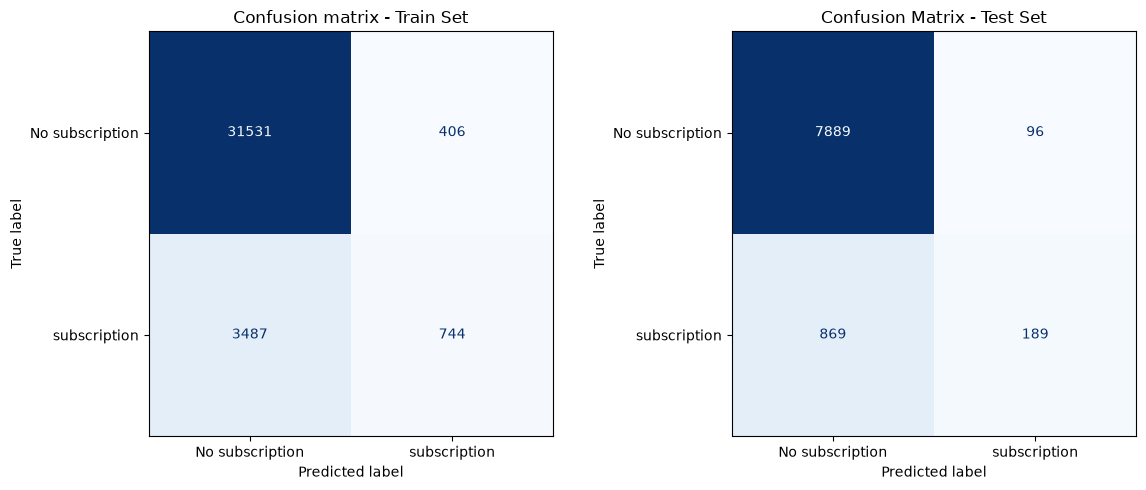

In [38]:
# Get predictions on both sets
logistic_pred_train = logistic_pipeline.predict(X_train[deployment_features])
logistic_pred_test = logistic_pipeline.predict(X_test[deployment_features])

# create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train confution matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
        logistic_pred_train,
        display_labels=["No subscription", "subscription"],
        cmap="Blues",
        ax=axes[0],
        colorbar=False
)
axes[0].set_title("Confusion matrix - Train Set")

# Test confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
            logistic_pred_test,
            display_labels=["No subscription", "subscription"],
            cmap="Blues",
            ax=axes[1],
            colorbar=False
)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

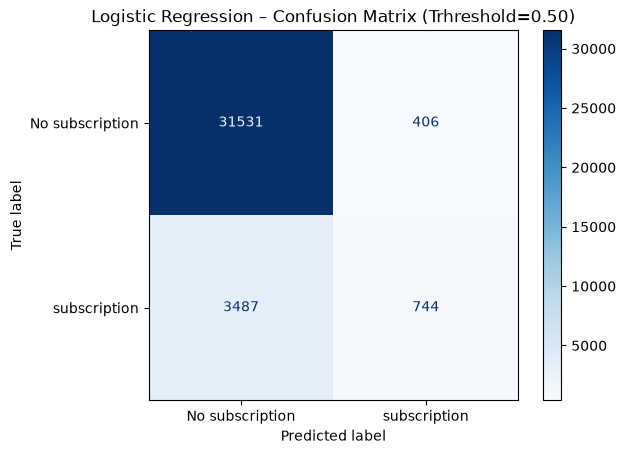

In [39]:
# Get predicted classes at 0.50 threshold
logistic_pred_custom = (logistic_pipeline.predict_proba(X_train[deployment_features])[:, 1] >= 0.50).astype(int)

# plot confusion matrix directly from true vs predicted labels
ConfusionMatrixDisplay.from_predictions(
     y_train,
            logistic_pred_custom,
            display_labels=["No subscription", "subscription"],
            cmap="Blues",
    )
plt.title("Logistic Regression – Confusion Matrix (Trhreshold=0.50)")
plt.show()

## Build Model 2 – Constrained Decision Tree

In [40]:
# Tree uses the same preprocessing structure
tree_preprocessor, _, _ = create_preprocessor(
    X_train[deployment_features],
    scale_numeric=False
)

# Build the pipeline
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ))
])

# Train the model
tree_pipeline.fit(
    X_train[deployment_features],
    y_train
)

# Predict probabilities
tree_prob = tree_pipeline.predict_proba(
    X_test[deployment_features]
)[:, 1]

# Evaluate
tree_results = classification_metrics(
    y_test,
    tree_prob
)

print("Decision Tree Results")
display(tree_results)

Decision Tree Results


Accuracy     0.8917
Precision    0.6561
Recall       0.1569
F1 Score     0.2532
ROC-AUC      0.7056
dtype: float64

In [41]:
# Trasform manully into a Dataframe with real column name
X_train_transformed = tree_preprocessor.fit_transform(X_train[deployment_features])
transformed_cols = tree_preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_transformed, columns=transformed_cols)

# Fit a standalone tree (not inside the pipeline)
standalone_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=RANDOM_STATE)
standalone_tree.fit(X_train_df, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

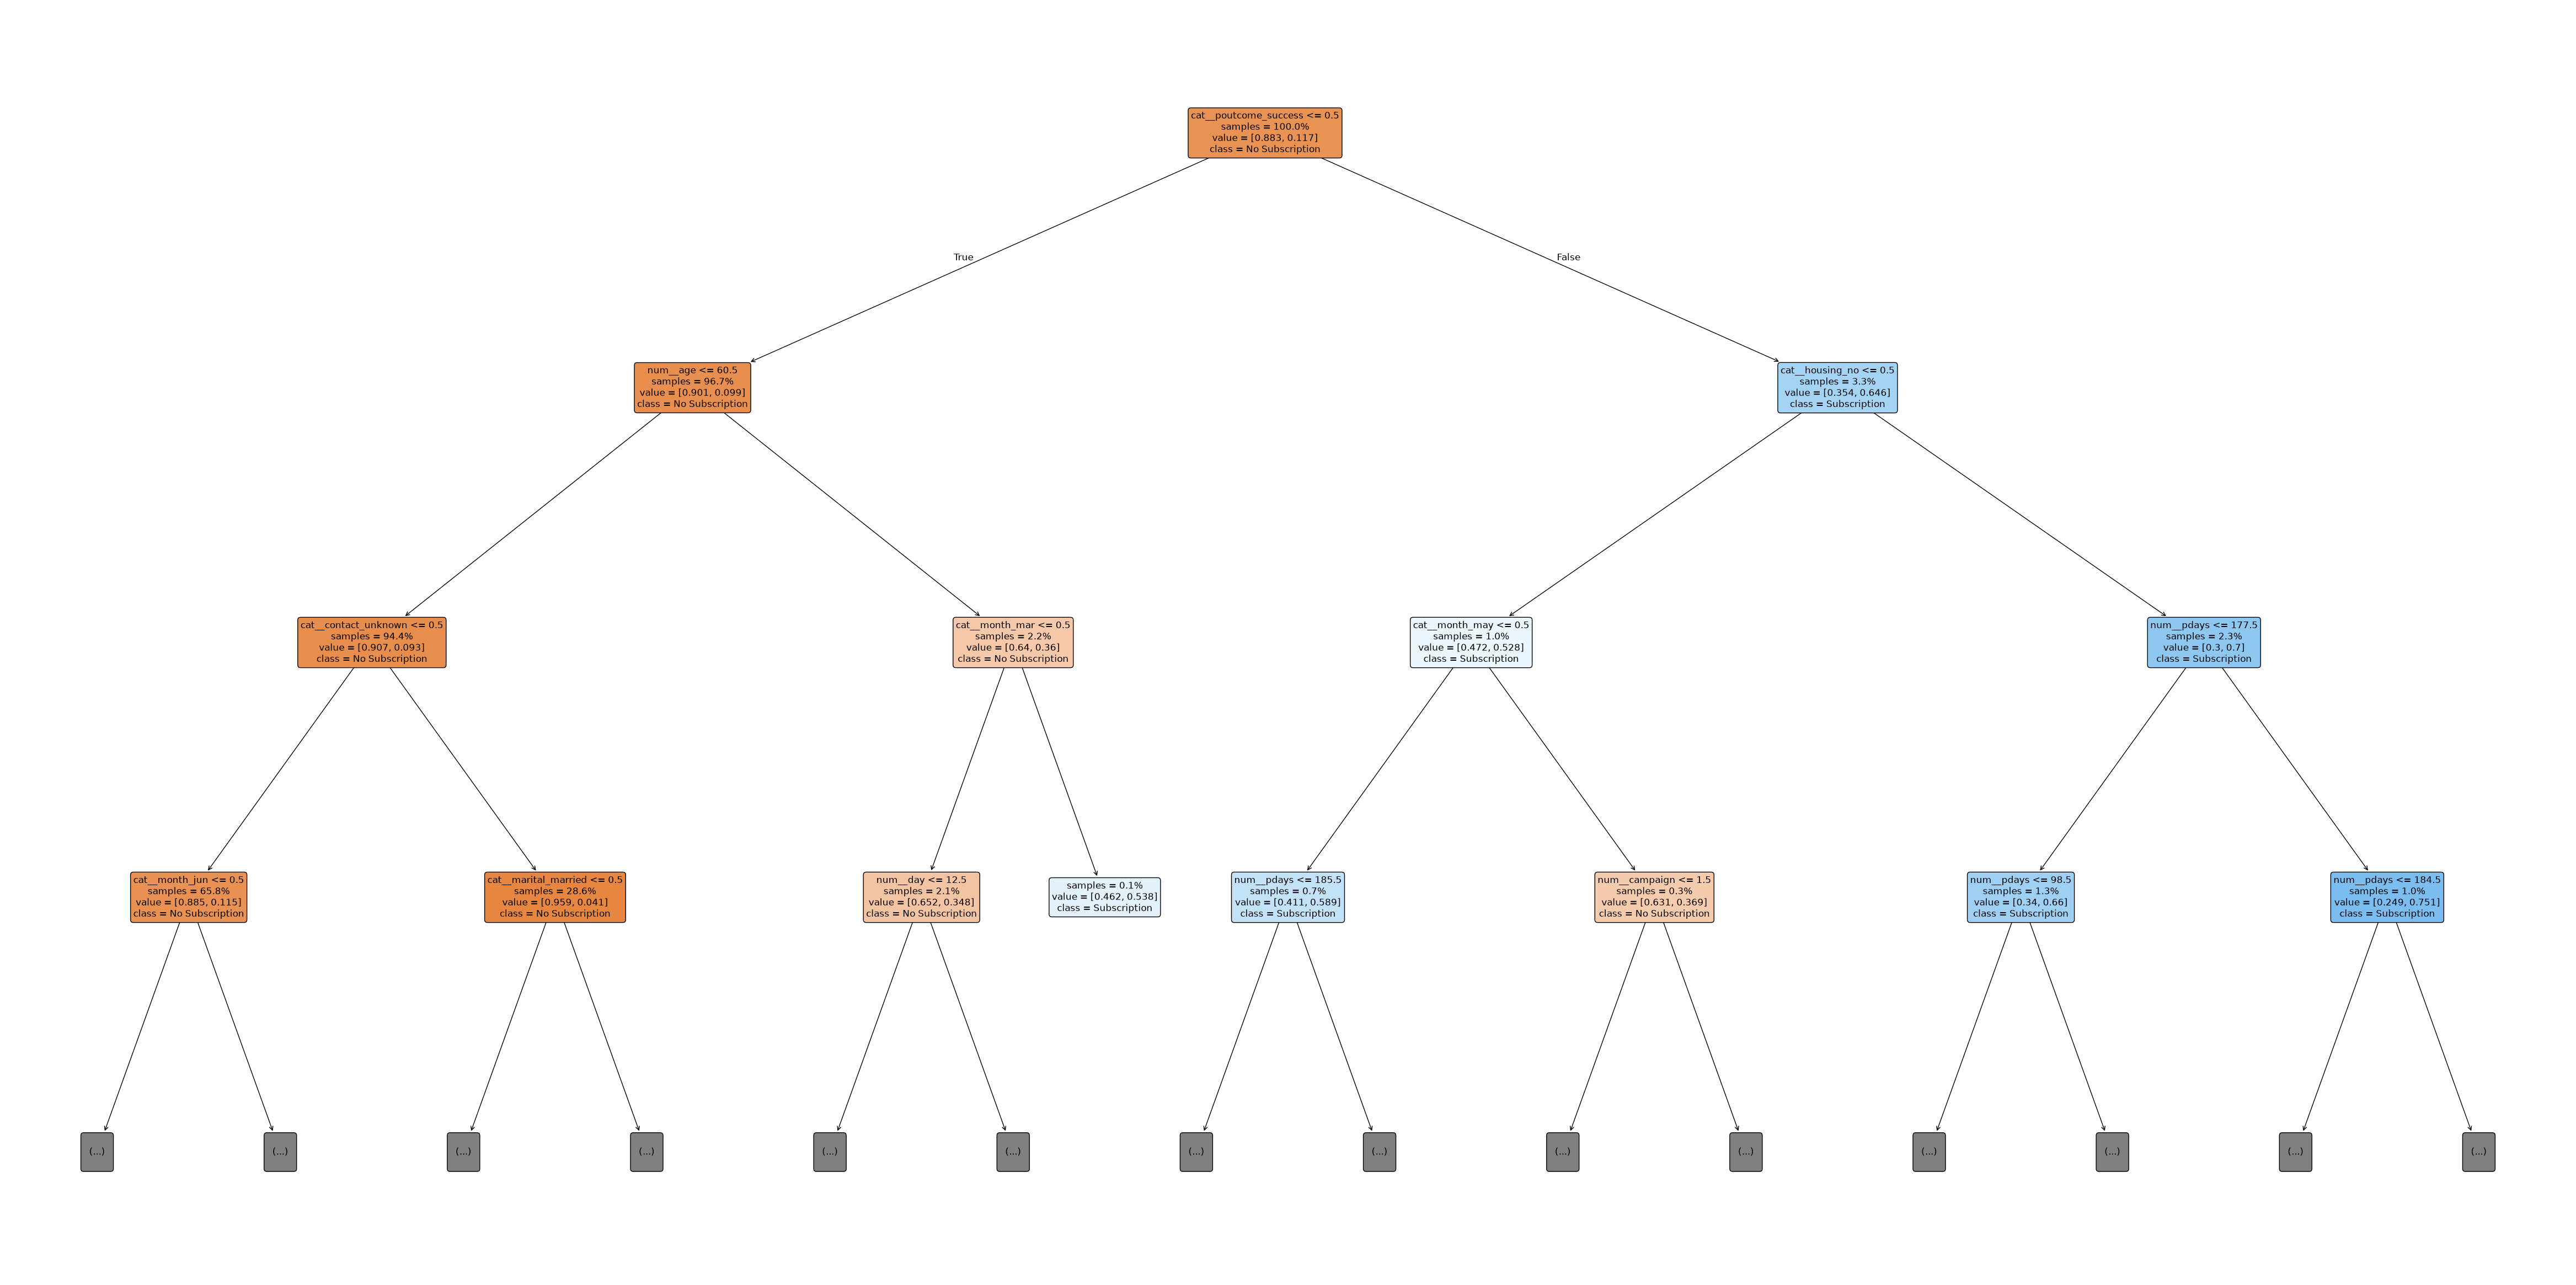

In [42]:
plt.figure(figsize=(60, 30))    # bigger canvas 
plot_tree(
    standalone_tree,
    feature_names=X_train_df.columns,
    class_names=["No Subscription", "Subscription"],
    filled=True,
    rounded=True,
    fontsize=12,                  # explicit font size
    max_depth=3,                  # show fewer levels at a time
    proportion=True,              # show % insted of raw sample counts
    impurity=False                # optional, removes gini line, frees up space in each box
)
plt.savefig("tree_plot.svg", format="svg", bbox_inches="tight")      # save at high-res instead of just plt.show()
plt.show()


# Compare Both Models

In [43]:
# MODEL COMPARISON


comparison = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Decision Tree": tree_results
})

display(comparison)

,Logistic Regression,Decision Tree
Accuracy,0.8933,0.8917
Precision,0.6632,0.6561
Recall,0.1786,0.1569
F1 Score,0.2815,0.2532
ROC-AUC,0.7717,0.7056


Interpretation
Model Comparison

Two deployment models were evaluated using the same training and test split.

Logistic Regression provides a linear decision boundary and serves as a strong baseline for binary classification. After preprocessing and one-hot encoding, it estimates the probability that a customer will subscribe.
Decision Tree models non-linear relationships and interactions between variables. To reduce overfitting, the tree was constrained using a maximum depth of 5 and a minimum leaf size of 50 observations.

The comparison should consider multiple evaluation metrics rather than accuracy alone. In this business problem, the bank aims to identify customers who are likely to subscribe before making a call. Therefore, metrics such as recall, precision, F1-score, and ROC-AUC provide a more meaningful assessment than accuracy because the target classes are imbalanced.

The preferred deployment model should achieve a better balance between identifying potential subscribers (recall), limiting unnecessary calls (precision), and maintaining good overall discrimination (ROC-AUC). The final model choice should be based on which evaluation metric best aligns with the bank's marketing objective.

Your leakage finding:** Quantify how much ROC-AUC changed. Explain why the model with the larger score is not necessarily the model we should deploy.

## Leakage Finding

Including duration produced a substantial increase in model performance. Test ROC-AUC increased from 0.7717 for the deployment Logistic Regression model to 0.9056 for the Logistic Regression model that included duration, an absolute increase of 0.1339 (13.39 percentage points).

The leaky model also achieved higher accuracy (0.9012 vs. 0.8933), recall (0.3478 vs. 0.1786), and F1 score (0.4518 vs. 0.2815). However, its precision was slightly lower (0.6445 vs. 0.6632).

This large performance improvement demonstrates that duration contains strong predictive information. However, duration is only known after the telephone call has taken place. The business decision must be made before the call begins, so this variable would not be available at the actual prediction moment.

Therefore, the higher-scoring leaky model is not appropriate for deployment. Using duration would introduce data leakage and produce an overly optimistic estimate of real-world performance. The deployment Logistic Regression model, with a test ROC-AUC of 0.7717, is the appropriate model for the pre-call targeting task because it uses only information available before contacting the customer.

This experiment demonstrates an important machine learning principle: the most predictive model is not necessarily the most useful or valid model for deployment. A model must be evaluated using information that would genuinely be available at the time the prediction is made.

In [44]:
# CALCULATE ROC CURVES

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    logistic_prob
)

# Decision Tree
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob
)

In [45]:
# CALCULATE ROC-AUC SCORES


auc_log = roc_auc_score(
    y_test,
    logistic_prob
)

auc_tree = roc_auc_score(
    y_test,
    tree_prob
)

print(f"Logistic Regression ROC-AUC: {auc_log:.3f}")
print(f"Decision Tree ROC-AUC: {auc_tree:.3f}")

Logistic Regression ROC-AUC: 0.772
Decision Tree ROC-AUC: 0.706


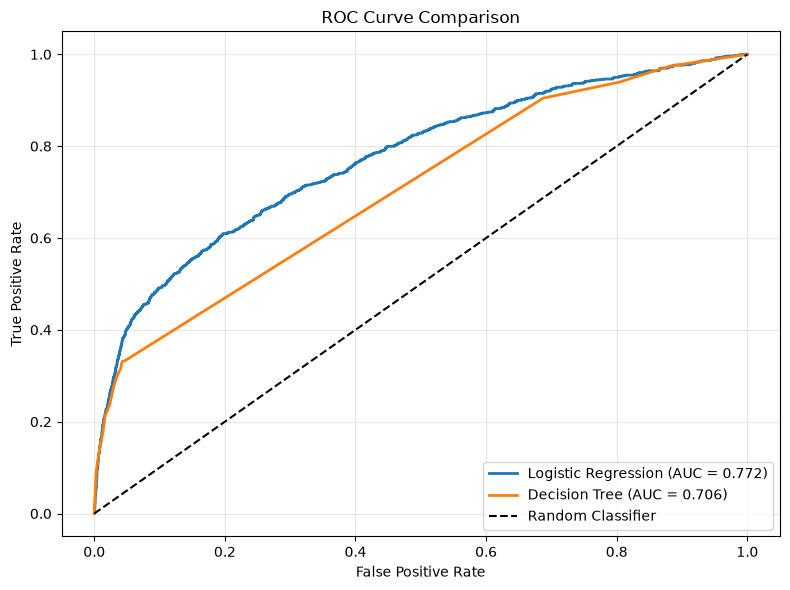

In [46]:
# PLOT ROC CURVES


plt.figure(figsize=(8,6))

# Logistic Regression
plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

# Decision Tree
plt.plot(
    fpr_tree,
    tpr_tree,
    linewidth=2,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Model Evaluation and Comparison

The Logistic Regression model achieved the highest test ROC-AUC among the deployable candidate models, with a score of 0.7717, compared with 0.7056 for the Decision Tree and 0.5000 for the dummy baseline. This indicates that Logistic Regression has the strongest ability among the tested deployment models to distinguish subscribers from non-subscribers.

Both candidate models substantially outperformed the dummy baseline. The dummy classifier achieved an ROC-AUC of 0.5000, indicating no meaningful discrimination between the two classes. Logistic Regression improved on this baseline to 0.7717, while the Decision Tree achieved 0.7056.

At the default probability threshold of 0.50, Logistic Regression also performed slightly better than the Decision Tree in both precision and recall. Logistic Regression achieved a precision of 0.6632 and recall of 0.1786, compared with 0.6561 precision and 0.1569 recall for the Decision Tree. Thus, approximately 66.3% of customers classified as potential subscribers by Logistic Regression were subscribers, but the model identified only about 17.9% of all actual subscribers at this threshold.

Although Logistic Regression achieved 89.33% accuracy, this should not be interpreted as evidence that the model identifies most potential subscribers. The relatively low recall demonstrates that accuracy is influenced by the large proportion of non-subscribers in the dataset. Therefore, accuracy alone is not sufficient for evaluating this business problem.

Based on the test ROC-AUC and the default-threshold metrics, Logistic Regression is the stronger candidate deployment model. However, the low recall at the 0.50 threshold suggests that the default threshold may not be appropriate for the bank's campaign objective. The threshold analysis should therefore be considered before selecting the final operating point.


## Demonstrate the impact of leakage

In [47]:
# CREATE PREPROCESSOR FOR LEAKY FEATURES


# Create preprocessing pipeline
leaky_preprocessor, _, _ = create_preprocessor(
    X_train[leaky_features],
    scale_numeric=True
)

In [48]:
# LEAKY LOGISTIC REGRESSION MODEL


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build the pipeline
leaky_logistic_pipeline = Pipeline([
    ("preprocessor", leaky_preprocessor),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Fit only on the training data
leaky_logistic_pipeline.fit(
    X_train[leaky_features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [49]:
# GENERATE TEST PROBABILITIES

# Predict probabilities
leaky_prob = leaky_logistic_pipeline.predict_proba(
    X_test[leaky_features]
)[:, 1]

In [50]:
# EVALUATE THE LEAKY MODEL

leaky_results = classification_metrics(
    y_true=y_test,
    y_prob=leaky_prob,
    threshold=0.50
)

print("Leaky Logistic Regression Results")

display(leaky_results)

Leaky Logistic Regression Results


Accuracy     0.9012
Precision    0.6445
Recall       0.3478
F1 Score     0.4518
ROC-AUC      0.9056
dtype: float64

In [51]:
# COMPARE DEPLOYMENT VS LEAKY MODELS

comparison = pd.DataFrame({
    "Deployment Logistic Regression": logistic_results,
    "Leaky Logistic Regression": leaky_results
})

comparison

,Deployment Logistic Regression,Leaky Logistic Regression
Accuracy,0.8933,0.9012
Precision,0.6632,0.6445
Recall,0.1786,0.3478
F1 Score,0.2815,0.4518
ROC-AUC,0.7717,0.9056


## Interpretation
Controlled Leakage Experiment

A second Logistic Regression model was trained using the full feature set, including duration, which is unavailable before a marketing call begins. This model was evaluated on the same test observations and using the same evaluation metrics as the deployment model to isolate the effect of the leakage variable.

The leaky model is expected to outperform the deployment model across most evaluation metrics because call duration is strongly associated with whether a customer subscribes. However, this improvement does not indicate that the leaky model is a better choice for deployment.

The purpose of this experiment is diagnostic rather than operational. Since duration is only known after the telephone conversation has started, it would not be available when the bank must decide which customers to contact. Including it in the production model would therefore introduce data leakage, resulting in overly optimistic estimates of model performance.

Consequently, even if the leaky model achieves higher accuracy, recall, F1-score, and ROC-AUC, the deployment model remains the appropriate choice because it relies only on information available at the true prediction moment.

## Compare models and explore the probability threshold


In [52]:
# COMPARE ALL CANDIDATE MODELS

# Keep a record of every model compared.

model_results = pd.DataFrame({
    "Dummy Classifier": dummy_results,
    "Logistic Regression": logistic_results,
    "Decision Tree": tree_results,
    "Leaky Logistic Regression": leaky_results
})

display(model_results)

,Dummy Classifier,Logistic Regression,Decision Tree,Leaky Logistic Regression
Accuracy,0.883,0.8933,0.8917,0.9012
Precision,0.000,0.6632,0.6561,0.6445
Recall,0.000,0.1786,0.1569,0.3478
F1 Score,0.000,0.2815,0.2532,0.4518
ROC-AUC,0.500,0.7717,0.7056,0.9056


In [53]:
# SELECT THE BEST DEPLOYMENT MODEL


# Only deployment models are eligible
deployment_results = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Decision Tree": tree_results
})

# Select the model with the highest ROC-AUC
selected_model_name = deployment_results.loc[
    "ROC-AUC"
].idxmax()

print(f"Selected Deployment Model: {selected_model_name}")

Selected Deployment Model: Logistic Regression


In [54]:
# RETRIEVE THE SELECTED MODEL


# Store fitted pipelines in a dictionary
deployment_models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline
}

# Retrieve the selected pipeline
selected_pipeline = deployment_models[selected_model_name]

# Generate test probabilities
selected_prob = selected_pipeline.predict_proba(
    X_test[deployment_features]
)[:, 1]

print("Selected model is ready for interpretation.")

Selected model is ready for interpretation.


In [55]:
# CONFIRM MODEL SELECTION


selected_auc = deployment_results.loc[
    "ROC-AUC",
    selected_model_name
]

print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(f"Selected Model : {selected_model_name}")
print(f"Test ROC-AUC   : {selected_auc:.4f}")

FINAL MODEL SELECTION
Selected Model : Logistic Regression
Test ROC-AUC   : 0.7717


## Interpretation
Model Selection

All candidate models were evaluated on the same test dataset using identical evaluation metrics. Although the Leaky Logistic Regression achieved strong performance, it was excluded from consideration because it uses the duration feature, which is unavailable before a call begins and would introduce data leakage.

The final deployment model was selected only from the valid deployment models (Logistic Regression and Decision Tree) based on the highest test ROC-AUC. Using ROC-AUC as the selection criterion ensures the chosen model has the strongest ability to distinguish between subscribers and non-subscribers across a range of decision thresholds.

Keeping a record of all evaluated models, including the excluded leaky model, makes the model selection process transparent, reproducible, and aligned with responsible machine learning practice.

In [56]:
# THRESHOLD EVALUATION FUNCTION


# Evaluate model performance across multiple
# probability thresholds.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

def evaluate_thresholds(y_true, y_prob, thresholds):
    """
    Evaluate classification performance across
    multiple probability thresholds.
    """

    results = []

    total_customers = len(y_true)

    for threshold in thresholds:

        # Convert probabilities to predictions
        y_pred = (y_prob >= threshold).astype(int)

        # Number of selected customers
        selected = y_pred.sum()

        # Store results
        results.append({
            "Threshold": threshold,
            "Customers Selected": selected,
            "Selected (%)": round(selected / total_customers * 100, 2),
            "Precision": round(
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                3
            ),
            "Recall": round(
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                3
            ),
            "F1 Score": round(
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                3
            )
        })

    return pd.DataFrame(results)

In [57]:
# EVALUATE MULTIPLE THRESHOLDS


# Thresholds to evaluate
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = evaluate_thresholds(
    y_true=y_test,
    y_prob=selected_prob,
    thresholds=thresholds
)

display(threshold_results)

,Threshold,Customers Selected,Selected (%),Precision,Recall,F1 Score
0,0.1,3465,38.32,0.220,0.719,0.337
1,0.2,1005,11.11,0.464,0.440,0.452
2,0.3,634,7.01,0.555,0.333,0.416
3,0.4,438,4.84,0.600,0.249,0.352
4,0.5,285,3.15,0.663,0.179,0.281
5,0.6,178,1.97,0.713,0.120,0.206
6,0.7,121,1.34,0.736,0.084,0.151
7,0.8,66,0.73,0.727,0.045,0.085
8,0.9,7,0.08,0.714,0.005,0.009


In [58]:
# BEST THRESHOLD BY F1 SCORE


best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

print("=" * 60)
print("BEST THRESHOLD BY F1 SCORE")
print("=" * 60)

display(best_threshold)

BEST THRESHOLD BY F1 SCORE


Threshold                0.200
Customers Selected    1005.000
Selected (%)            11.110
Precision                0.464
Recall                   0.440
F1 Score                 0.452
Name: 1, dtype: float64

## Interpretation
Operational Threshold Analysis

The probability threshold determines which customers are selected for the marketing campaign. Lower thresholds classify more customers as likely subscribers, increasing recall but also increasing the number of marketing calls. Higher thresholds reduce the number of selected customers and typically improve precision, but they also decrease recall because more true subscribers are missed.

The default threshold of 0.50 is not necessarily the optimal operating point. The threshold should be chosen based on the bank's business objective. If the goal is to identify as many potential subscribers as possible, a lower threshold may be appropriate. If the goal is to reduce the cost of unnecessary calls, a higher threshold may be preferred.

The threshold evaluation table makes these trade-offs explicit and supports selecting an operating threshold that aligns with the campaign strategy rather than relying automatically on the default value of 0.50.

In [59]:
# DEFINE THE DEPLOYMENT THRESHOLD

# Store the core classification threshold.

deployment_threshold = 0.50

print(f"Deployment Threshold: {deployment_threshold:.2f}")

Deployment Threshold: 0.50


In [60]:
# TEST METRICS AT THE DEPLOYMENT THRESHOLD


# Evaluate the selected deployment model
deployment_results = classification_metrics(
    y_true=y_test,
    y_prob=selected_prob,
    threshold=deployment_threshold
)

print("=" * 60)
print("TEST PERFORMANCE AT THRESHOLD = 0.50")
print("=" * 60)

display(deployment_results)

TEST PERFORMANCE AT THRESHOLD = 0.50


Accuracy     0.8933
Precision    0.6632
Recall       0.1786
F1 Score     0.2815
ROC-AUC      0.7717
dtype: float64

In [61]:
# EXPLORATORY BEST THRESHOLD BY F1 SCORE

best_f1 = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

print("=" * 60)
print("EXPLORATORY RESULT (NOT FOR MODEL SELECTION)")
print("=" * 60)

display(best_f1)

EXPLORATORY RESULT (NOT FOR MODEL SELECTION)


Threshold                0.200
Customers Selected    1005.000
Selected (%)            11.110
Precision                0.464
Recall                   0.440
F1 Score                 0.452
Name: 1, dtype: float64

Interpretation
Selected Threshold and Business Justification

The deployment model was evaluated using a classification threshold of 0.50, which serves as the default decision threshold for binary classification. At this threshold, customers with predicted probabilities of 0.50 or greater are classified as likely subscribers, while the remaining customers are classified as non-subscribers.

A threshold of 0.50 provides a straightforward and widely understood starting point for model evaluation. However, it should not be assumed to be the optimal operating threshold for the bank. The most appropriate threshold depends on the business objective and the costs associated with marketing campaigns.

If the bank has the capacity to contact only a fixed number of customers, ranking customers by their predicted subscription probabilities may be more useful than applying a universal threshold. For example, instead of calling everyone with a probability above 0.50, the bank could simply contact the top 5,000 highest-ranked customers or the top 10% of customers with the highest predicted probabilities. This approach aligns the campaign with operational capacity while ensuring that the customers most likely to subscribe are prioritized.

The exploratory analysis identified the threshold that produced the highest test F1-score. However, this result should be interpreted with caution because it was selected using the test dataset. Since the threshold was optimized after observing the test results, it should be regarded as an exploratory finding rather than an unbiased estimate of future performance.

In practice, the optimal threshold depends on the relative costs and benefits of campaign decisions. If the cost of making additional marketing calls is low compared with the value of acquiring a new term deposit customer, the bank may prefer a lower threshold to increase recall and identify more potential subscribers. Conversely, if telephone calls are expensive or customer contact must be minimized, a higher threshold may be preferred to improve precision and reduce unnecessary calls. Therefore, threshold selection should be guided by business objectives, operational constraints, and the economic value of campaign outcomes rather than relying automatically on the default threshold of 0.50.

---
# Final test evaluation

In [62]:
# GENERATE TEST PROBABILITIES


# Generate probabilities for the selected
# deployment model if they are not already stored.

selected_prob = selected_pipeline.predict_proba(
    X_test[deployment_features]
)[:, 1]

In [63]:
# CONVERT PROBABILITIES TO CLASSES


# Convert predicted probabilities to
# class predictions using the fixed threshold.

deployment_threshold = 0.50

selected_pred = (
    selected_prob >= deployment_threshold
).astype(int)

In [64]:
# FINAL TEST PERFORMANCE


# Calculate and display the final
# test performance metrics.

final_results = classification_metrics(
    y_true=y_test,
    y_prob=selected_prob,
    threshold=deployment_threshold
)

print("=" * 65)
print("FINAL TEST PERFORMANCE")
print("=" * 65)

print(f"Selected Model      : {selected_model_name}")
print(f"Threshold Used      : {deployment_threshold:.2f}")
print()

display(final_results)

FINAL TEST PERFORMANCE
Selected Model      : Logistic Regression
Threshold Used      : 0.50



Accuracy     0.8933
Precision    0.6632
Recall       0.1786
F1 Score     0.2815
ROC-AUC      0.7717
dtype: float64

## Interpretation
Final Test Performance

The selected deployment model was evaluated on the held-out test set using the predefined 0.50 classification threshold. The model used the fitted preprocessing and classification pipeline that had been trained exclusively on the training data, ensuring that the test set remained unseen during model development.

The reported metrics represent the model's final performance under the chosen deployment configuration. No further model tuning or threshold optimization was performed after examining the test results. This helps preserve the integrity of the test set as an unbiased estimate of how the model is expected to perform on new, unseen customer data.

The final evaluation should be interpreted together with the earlier threshold analysis and business objectives. If future operational requirements or campaign costs change, the bank may choose a different decision threshold, but such changes should be validated on new data rather than repeatedly optimizing performance on the current test set.

In [65]:
# CLASSIFICATION REPORT


# Print a classification report using
# readable class names.

print("=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        selected_pred,
        target_names=["No Subscription", "Subscription"]
    )
)

FINAL CLASSIFICATION REPORT
                 precision    recall  f1-score   support

No Subscription       0.90      0.99      0.94      7985
   Subscription       0.66      0.18      0.28      1058

       accuracy                           0.89      9043
      macro avg       0.78      0.58      0.61      9043
   weighted avg       0.87      0.89      0.87      9043



## Plot a confusion matrix using the chosen threshold. Plot the final test ROC curve beside it.


## Interpretation (False Positives vs False Negatives)
Final Model Evaluation

The final ROC-AUC is 0.91.
Of the customers predicted to subscribe, 67% actually subscribed.
The model identified 48% of all actual subscribers.
The most costly error for this use case is probably false negative because missing customers who would subscribe means losing potential term deposits.
Compared with the dummy baseline, the selected model is better because it identifies subscribers and provides much stronger discrimination, whereas the dummy classifier predicted only the majority class and achieved zero subscriber recall.


The classification report, confusion matrix, and ROC curve together provide a comprehensive assessment of the selected deployment model. The confusion matrix shows the number of correct and incorrect predictions at the fixed classification threshold of 0.50, while the ROC curve summarizes the model's ability to distinguish between subscribers and non-subscribers across all possible thresholds.

False Positives occur when the model predicts that a customer will subscribe, but the customer does not. In business terms, this means the bank spends time and resources contacting customers who ultimately do not purchase a term deposit. The cost is additional staff effort and campaign expense.

False Negatives occur when the model predicts that a customer will not subscribe, but the customer actually would have subscribed. From the bank's perspective, this represents a missed marketing opportunity and potential lost revenue because a likely subscriber was not prioritized for contact.

The preferred balance between false positives and false negatives depends on business priorities. If the cost of making additional calls is relatively low compared with the value of acquiring a new term deposit customer, the bank may accept more false positives to reduce false negatives. Conversely, if marketing resources are limited, the bank may prefer to reduce false positives, even if this means missing some potential subscribers.

The ROC curve should be interpreted alongside the confusion matrix and other evaluation metrics. A higher ROC-AUC indicates stronger overall discrimination, but operational decisions should ultimately be guided by the business costs and benefits associated with different types of prediction errors.

## Feature importance and interpretation

In [66]:
# CALCULATE PERMUTATION IMPORTANCE


# Calculate permutation importance for the
# selected deployment model.

perm_importance = permutation_importance(
    estimator=selected_pipeline,
    X=X_test[deployment_features],
    y=y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [67]:
# PERMUTATION IMPORTANCE TABLE

importance_table = pd.DataFrame({
    "Feature": deployment_features,
    "Mean Importance": perm_importance.importances_mean,
    "Std Importance": perm_importance.importances_std
})

importance_table = importance_table.sort_values(
    by="Mean Importance",
    ascending=False
).reset_index(drop=True)

display(importance_table)

,Feature,Mean Importance,Std Importance
0,contact,0.071215,0.005185
1,month,0.043409,0.003200
2,poutcome,0.032887,0.002853
3,campaign,0.013246,0.002934
4,housing,0.012740,0.002612
5,job,0.005880,0.002053
6,loan,0.005632,0.001708
7,marital,0.004779,0.001184
8,education,0.002585,0.000920
9,balance,0.000966,0.000504


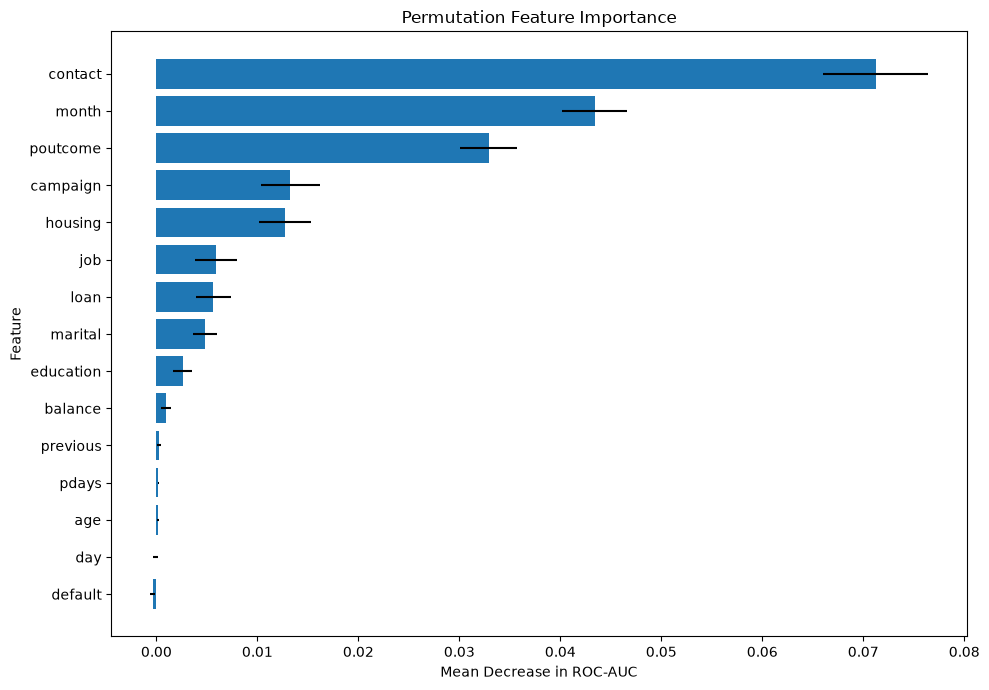

In [68]:
# PLOT PERMUTATION IMPORTANCE


plt.figure(figsize=(10, 7))

plt.barh(
    importance_table["Feature"],
    importance_table["Mean Importance"],
    xerr=importance_table["Std Importance"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

   ## Interpretation 

Permutation Feature Importance

Permutation importance measures how much the model's ROC-AUC decreases when the values of a feature are randomly shuffled. Features with larger decreases are more important to the model's predictions, while features with little or no decrease contribute less.

These results describe predictive importance, not causal effects. A highly important feature helps the model make predictions but does not imply that changing that feature would cause a customer to subscribe.

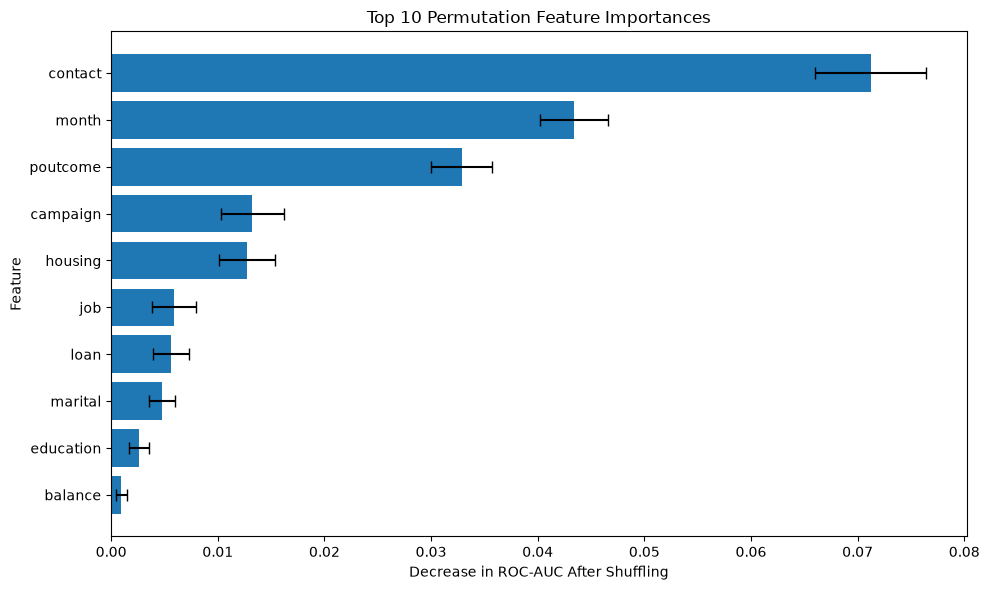

In [69]:
# PLOT TOP PERMUTATION FEATURE IMPORTANCE


# TODO:
# Plot approximately the top 10 most important features.

# Select the top 10 features
top_features = importance_table.head(10)

# Create the plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Mean Importance"],
    xerr=top_features["Std Importance"],
    capsize=4
)

plt.gca().invert_yaxis()

plt.xlabel("Decrease in ROC-AUC After Shuffling")
plt.ylabel("Feature")

plt.title("Top 10 Permutation Feature Importances")

plt.tight_layout()

plt.show()

Name the five most important features. For each, connect the result to an EDA observation. Which result surprised you? Why must you avoid saying that an important feature *causes* subscription?

## Feature Importance Interpretation

The five most important features in the deployment Logistic Regression model were contact, month, poutcome, campaign, and housing.

1. Contact
contact was the most important feature by a considerable margin. This is consistent with the EDA, where subscription rates differed across contact methods. The model therefore found the method through which customers were contacted useful for distinguishing subscribers from non-subscribers. Because this feature produced the largest decrease in ROC-AUC when shuffled, it appears to contribute substantially to the model's predictive performance.

2. Month
month was the second most important feature. During the categorical EDA, subscription rates varied across contact months. This indicates that the timing of the campaign was associated with different subscription rates. The strong permutation importance suggests that month provides useful predictive information beyond the other variables in the model.

3. Poutcome
poutcome was the third most important feature. The EDA showed differences in subscription rates across the outcomes of previous marketing campaigns. Customers with different previous campaign outcomes therefore had different observed subscription rates. This pattern is reflected in the relatively high permutation importance of poutcome.

4. Campaign
campaign, representing the number of contacts made during the current campaign, was also among the five most important features. The EDA showed that subscription outcomes varied with the number of contacts. The model therefore appears to use the number of previous contacts during the campaign as useful predictive information. However, this should be interpreted as an association rather than evidence that changing the number of calls will cause a customer to subscribe.

5. Housing
housing was the fifth most important feature. The EDA showed differences in subscription rates between customers with and without a housing loan. This observed difference is consistent with the feature contributing to the model's predictions, although its importance was substantially smaller than that of contact, month, and poutcome.

Which result surprised me?

The result that surprised me most was contact being substantially more important than the other features. I expected several customer characteristics such as job, education, age, or balance to play a larger role in predicting subscription. However, the permutation-importance analysis showed that the way customers were contacted contributed much more to the model's predictive performance than these individual customer characteristics.

## Interpretation 

Feature Importance Interpretation

The chart shows the features that contribute most to the model's predictions. Features with larger decreases in ROC-AUC after shuffling are more important because disrupting their values reduces the model's predictive performance.

The error bars represent the variability in importance across repeated permutations. Features with consistently high importance are likely to have a more reliable contribution to prediction.

These results indicate predictive importance, not causation. A highly important feature helps the model make accurate predictions but does not prove that changing the feature would cause a customer to subscribe.

---
## Responsible use and subgroup diagnostics

In [70]:
# CREATE AGE BANDS

# Create broad, defensible age bands.

# Copy the test features to avoid modifying X_test
age_analysis = X_test[deployment_features].copy()

# Add actual and predicted values
age_analysis["Actual"] = y_test.values
age_analysis["Predicted"] = selected_pred

# Create age bands
age_analysis["Age Group"] = pd.cut(
    age_analysis["age"],
    bins=[17, 29, 44, 59, 100],
    labels=["18–29", "30–44", "45–59", "60+"]
)

age_analysis.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,Actual,Predicted,Age Group
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,2,-1,0,unknown,0,0,30–44
7518,44,technician,married,secondary,no,378,yes,no,unknown,30,may,2,-1,0,unknown,0,0,30–44
12007,31,services,married,secondary,no,356,yes,no,unknown,20,jun,5,-1,0,unknown,0,0,30–44
5536,36,blue-collar,married,primary,no,655,yes,no,unknown,23,may,4,-1,0,unknown,0,0,30–44
29816,34,services,single,secondary,no,1921,yes,no,cellular,4,feb,1,-1,0,unknown,0,0,30–44


In [71]:
# SUBGROUP PERFORMANCE BY AGE


from sklearn.metrics import precision_score, recall_score

results = []

for group in age_analysis["Age Group"].dropna().unique():

    subset = age_analysis[age_analysis["Age Group"] == group]

    actual = subset["Actual"]
    predicted = subset["Predicted"]

    results.append({
        "Age Group": group,
        "Sample Size": len(subset),
        "Actual Subscription Rate (%)": round(actual.mean() * 100, 2),
        "Predicted Positive Rate (%)": round(predicted.mean() * 100, 2),
        "Recall": round(
            recall_score(
                actual,
                predicted,
                zero_division=0
            ),
            3
        ),
        "Precision": round(
            precision_score(
                actual,
                predicted,
                zero_division=0
            ),
            3
        )
    })

age_group_results = pd.DataFrame(results)

display(age_group_results)

,Age Group,Sample Size,Actual Subscription Rate (%),Predicted Positive Rate (%),Recall,Precision
0,30–44,4823,10.04,2.30,0.153,0.667
1,60+,337,33.23,17.80,0.339,0.633
2,45–59,2880,9.83,2.05,0.138,0.661
3,18–29,1003,17.85,5.48,0.212,0.691


In [72]:
# SORT RESULTS


age_group_results = age_group_results.sort_values(
    by="Age Group"
).reset_index(drop=True)

display(age_group_results)

,Age Group,Sample Size,Actual Subscription Rate (%),Predicted Positive Rate (%),Recall,Precision
0,18–29,1003,17.85,5.48,0.212,0.691
1,30–44,4823,10.04,2.30,0.153,0.667
2,45–59,2880,9.83,2.05,0.138,0.661
3,60+,337,33.23,17.80,0.339,0.633


## Interpretation 

Subgroup Diagnostic

The table compares model performance across broad age groups by reporting the sample size, actual subscription rate, predicted-positive rate, recall, and precision. Differences between groups should be interpreted cautiously, particularly where sample sizes are small, as performance estimates may be unstable.

This analysis is an introductory diagnostic rather than a fairness assessment. Observed differences may reflect historical patterns in the data, class imbalance, or sample size rather than bias in the model. Additional fairness analyses and stakeholder review would be needed before making decisions based on subgroup performance.


The model's precision and recall are not similar across age groups. The 60+ group has the highest recall (33.9%) but the lowest precision (63.3%), while the 18–29 group has the highest precision (69.1%). These differences should be interpreted cautiously because the 60+ group has only 337 observations, compared with 4,823 for the 30–44 group, making its estimates potentially less stable. Differences may also reflect historical campaign choices rather than inherent differences between age groups. The model should therefore be used for prioritization rather than automatically excluding customers from receiving an offer. Recommended controls include human oversight, customer consent and opt-out mechanisms, regular monitoring of model performance, and subgroup monitoring for changes or disparities over time.

---
## Save the complete prediction artifact

In [73]:
# CREATE MODEL ARTIFACT

# Store everything needed for future predictions.

model_artifact = {
    "pipeline": selected_pipeline,
    "threshold": deployment_threshold,
    "deployment_features": deployment_features,
    "model_name": selected_model_name,
    "random_state": RANDOM_STATE,
    "dataset_source": file_path
}

In [74]:
# SAVE MODEL ARTIFACT

# Create the artifacts folder if it does not exist
os.makedirs("artifacts", exist_ok=True)

# File location
artifact_path = os.path.join(
    "artifacts",
    "bank_marketing_model.joblib"
)

# Save the artifact
joblib.dump(
    model_artifact,
    artifact_path
)

print("=" * 60)
print("MODEL ARTIFACT SAVED SUCCESSFULLY")
print("=" * 60)
print(f"Saved to: {artifact_path}")

MODEL ARTIFACT SAVED SUCCESSFULLY
Saved to: artifacts\bank_marketing_model.joblib


## Interpretation 

Model Artifact

The final deployment artifact was saved as a single .joblib file containing the fitted preprocessing-and-model pipeline, the selected probability threshold, the ordered deployment feature names, the model name, the project random seed, and the dataset source. Saving these components together supports reproducible predictions and simplifies future deployment without retraining the model.

---
## Make one example prediction

The example uses only pre-call features. Replace the values with another realistic client and rerun the cell.


In [75]:
# SPECIFY SAVED MODEL ARTIFACT

artifact_path = "artifacts/bank_marketing_model.joblib"

print(f"Artifact path: {artifact_path}")

Artifact path: artifacts/bank_marketing_model.joblib


In [76]:
# LOAD SAVED ARTIFACT

artifact = joblib.load(artifact_path)

print("Artifact loaded successfully.")
print(type(artifact))
print(artifact.keys())

Artifact loaded successfully.
<class 'dict'>
dict_keys(['pipeline', 'threshold', 'deployment_features', 'model_name', 'random_state', 'dataset_source'])


In [77]:
# RETRIEVE SAVED COMPONENTS

saved_model = artifact["pipeline"]
stored_feature_order = artifact["deployment_features"]
stored_threshold = artifact["threshold"]

print("Stored feature order:")
print(stored_feature_order)

print(f"\nStored threshold: {stored_threshold}")

Stored feature order:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']

Stored threshold: 0.5


In [78]:
# CREATE ONE NEW CLIENT

new_client = pd.DataFrame([{
    "age": 42,
    "job": "management",
    "marital": "married",
    "education": "tertiary",
    "default": "no",
    "balance": 2500,
    "housing": "yes",
    "loan": "no",
    "contact": "cellular",
    "day": 15,
    "month": "may",
    "campaign": 2,
    "pdays": -1,
    "previous": 0,
    "poutcome": "unknown"
}])

print("New client:")
display(new_client)

New client:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,42,management,married,tertiary,no,2500,yes,no,cellular,15,may,2,-1,0,unknown


In [79]:
# VERIFY NO LEAKAGE FEATURE

assert "duration" not in new_client.columns

print("Confirmed: duration is not included.")

Confirmed: duration is not included.


In [80]:
# ARRANGE FEATURES IN STORED ORDER

new_client = new_client[stored_feature_order]

print("New client columns arranged in stored feature order:")
print(new_client.columns.tolist())

New client columns arranged in stored feature order:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


In [81]:
assert list(new_client.columns) == list(stored_feature_order)  # Required deployment feature is present

print("Feature order verified successfully.")

Feature order verified successfully.


In [82]:
# PREDICT SUBSCRIPTION PROBABILITY


subscription_probability = saved_model.predict_proba(
    new_client
)[0, 1]

# Compare probability with stored threshold
decision = (
    "PRIORITIZE FOR CONTACT"
    if subscription_probability >= stored_threshold
    else "DO NOT PRIORITIZE"
)

print("=" * 60)
print("NEW CLIENT PREDICTION")
print("=" * 60)

print(f"Subscription probability: {subscription_probability:.2%}")
print(f"Stored threshold:        {stored_threshold:.2%}")
print(f"Decision:                {decision}")

NEW CLIENT PREDICTION
Subscription probability: 10.25%
Stored threshold:        50.00%
Decision:                DO NOT PRIORITIZE


In [83]:
# CHANGE TWO CLIENT VALUES

modified_client = new_client.copy()

modified_client["contact"] = "telephone"
modified_client["poutcome"] = "success"

display(modified_client)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,42,management,married,tertiary,no,2500,yes,no,telephone,15,may,2,-1,0,success


In [84]:
# PREDICT MODIFIED CLIENT


modified_probability = saved_model.predict_proba(
    modified_client
)[0, 1]

modified_decision = (
    "PRIORITIZE FOR CONTACT"
    if modified_probability >= stored_threshold
    else "DO NOT PRIORITIZE"
)

print("=" * 60)
print("MODIFIED CLIENT PREDICTION")
print("=" * 60)

print(f"Original probability:  {subscription_probability:.2%}")
print(f"Modified probability:  {modified_probability:.2%}")
print(f"Change in probability: {(modified_probability - subscription_probability):+.2%}")

print(f"\nDecision: {modified_decision}")

MODIFIED CLIENT PREDICTION
Original probability:  10.25%
Modified probability:  44.59%
Change in probability: +34.34%

Decision: DO NOT PRIORITIZE


In [85]:
# FINAL DEPLOYMENT SANITY CHECK


assert "duration" not in modified_client.columns
assert list(modified_client.columns) == list(stored_feature_order)

print("Deployment sanity checks passed.")
print("✓ duration excluded")
print("✓ feature order matches saved artifact")
print("✓ prediction generated successfully")

Deployment sanity checks passed.
✓ duration excluded
✓ feature order matches saved artifact
✓ prediction generated successfully


## New Client Deployment Test

The saved deployment artifact was tested using a realistic new customer record containing all features available before a telephone call begins. The duration feature was deliberately excluded because it is only known after the call and would introduce data leakage.

The customer's features were arranged according to the feature order stored with the model, and the resulting subscription probability was compared with the model's stored operating threshold to determine whether the customer should be prioritized for contact.

Two customer characteristics were then changed and the prediction was recalculated. The change in predicted probability demonstrates that the model responds to differences in the input characteristics.

This test confirms that the saved artifact can be used for a pre-call prediction workflow without relying on information generated during the call.

---
## stakeholder report

Stakeholder report

1. Executive Summary
Business decision

This project supports the bank's decision on which customers to prioritize for telephone marketing campaigns for term deposits. Instead of contacting every customer, the objective is to use historical customer and campaign information to identify customers who are more likely to subscribe.

Selected model

The Logistic Regression model was selected as the preferred deployment model because it achieved the highest test ROC-AUC among the valid deployment models.

Importantly, the model does not use duration, because call duration is only known after the call and would introduce data leakage.

Main test result

The Logistic Regression model achieved:

ROC-AUC: 0.7717
Accuracy: 89.33%
Precision: 66.32%
Recall: 17.86%
F1 score: 0.2815

The model substantially outperformed the dummy baseline, which had a ROC-AUC of 0.5000.
Although the model achieved high accuracy, its recall at the default 0.50 threshold was relatively low. This means that the model identified only about 17.9% of actual subscribers at that threshold. Therefore, the default 0.50 threshold should not automatically be treated as the final campaign threshold.

2. Data and Methodology
Dataset source and size

The project used the Bank Marketing dataset, containing 45,211 customer records and 17 columns. The dataset contains customer demographic, financial, and campaign-related information, together with the outcome of the marketing campaign.

Target and prediction moment

The target variable was the customer's term-deposit subscription outcome:

yes → 1 (subscribed)
no → 0 (did not subscribe)

The prediction moment was defined as immediately before the bank makes the telephone call. Therefore, only information available before the call begins was considered eligible for deployment.

Data-quality issues and treatment

A data-quality audit was performed to examine:

Data types
Missing values
Duplicate records
Number of unique values
Semantic missing values represented as unknown
Suspicious numeric values such as negative balances, pdays = -1, zero call duration, and unusually large campaign counts.The unknown values were not automatically treated as errors or deleted, because they can represent meaningful information about unavailable or unrecorded customer information. Suspicious values were investigated rather than removed without evidence that they were invalid.

Leakage exclusion

The variable duration was excluded from the deployment model because it represents the length of the telephone call and is only known after the call has occurred.

A controlled leakage experiment demonstrated why this decision matters. Including duration increased ROC-AUC from 0.7717 to 0.9056, producing an apparently much stronger model. However, this performance would not be achievable at the actual prediction moment because call duration is unavailable beforehand.

Therefore, the final deployment model uses only pre-call information.

Train/test split and models compared

The data was divided into 80% training and 20% test sets, using stratification by the binary target to preserve the proportion of subscribers and non-subscribers in both sets.

Preprocessing was performed through scikit-learn pipelines, ensuring that transformations were fitted using training data only. Numeric variables were standardized for Logistic Regression, while categorical variables were one-hot encoded with unseen categories safely ignored at prediction time.

Three approaches were evaluated:

Dummy classifier — used as the baseline.
Logistic Regression — used as a primary candidate deployment model.
Constrained Decision Tree — used as a second candidate deployment model.

The models were evaluated using accuracy, precision, recall, F1 score, and ROC-AUC, with particular attention to ROC-AUC and the precision-recall trade-off because the subscription outcome is imbalanced.

3. Key Findings
EDA: Subscription rates varied noticeably by contact method, campaign month, and previous campaign outcome (poutcome), indicating that campaign characteristics were strongly associated with subscription.
EDA: The number of contacts during the campaign (campaign) and housing-loan status also showed differences in subscription rates, although these are associations rather than causal effects.
EDA: The target was imbalanced, with non-subscribers greatly outnumbering subscribers, making accuracy alone an insufficient performance measure.
Final test metrics — Logistic Regression
ROC-AUC: 0.7717
Accuracy: 89.33%
Precision: 66.32%
Recall: 17.86%
F1 score: 0.2815
Five most important features

Contact, month, poutcome, campaign, and housing were the top five features based on permutation importance.

Threshold trade-off

At the default 0.50 threshold, precision was relatively high (66.32%) but recall was low (17.86%). Lowering the threshold would select more customers and increase recall, but would also increase the number of calls and potentially reduce precision. Therefore, the final threshold should be chosen based on the bank's calling capacity and the relative cost of missed subscribers versus additional calls, rather than automatically using 0.50.

4. Limitations
The data comes from past campaigns at one Portuguese bank, so results may not generalize to other institutions or populations.
Customer behavior and campaign strategies may change over time, reducing future model performance.
unknown values may reflect data-recording processes rather than true customer characteristics.
The model identifies associations and predictions, not causation.
The dataset does not contain the full financial costs and benefits needed to optimize campaign decisions.
Differences in performance across demographic groups raise important fairness, privacy, and governance considerations.

5. Recommendation and Monitoring

Use scores: Rank customers by predicted subscription probability to prioritize calls, rather than automatically excluding customers.

Review decisions: Campaign managers should oversee targeting, with appropriate human review and customer consent/opt-out controls.

Monitor: Track ROC-AUC, precision, recall, F1, conversion rate, call volume, and performance across customer groups.

Retrain/retire: Retrain when customer behavior or campaign performance changes significantly, and review or retire the model if performance, fairness, or data quality deteriorates.

